# **Project Name**    :Water Quality Classification for Public Health Monitoring Using Machine Learning

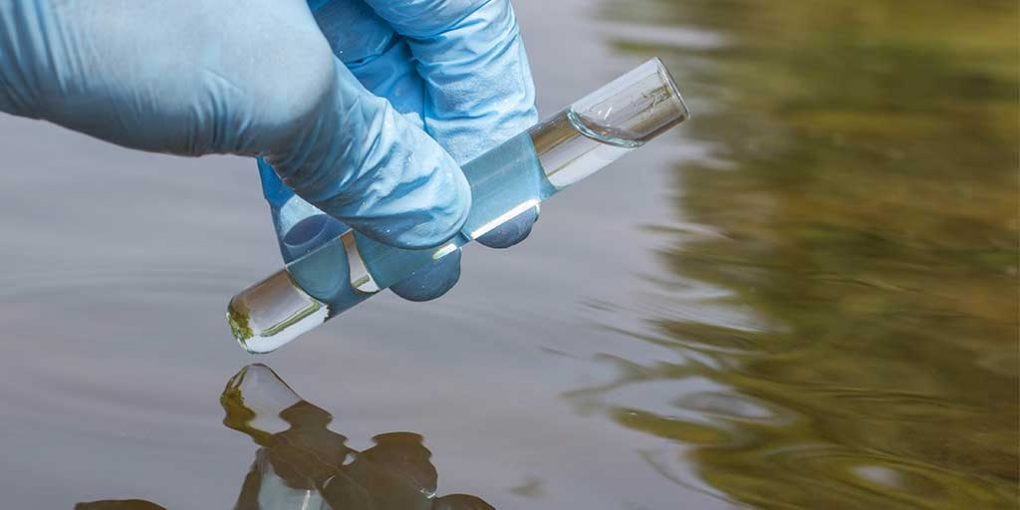

# **Project Summary**



* The main aim of this project is to build a machine learning classification model to predict whether a water sample belongs to High Quality (Class A) or Lower Quality (Classes B, C, and E) using environmental and chemical parameters.
  * The goal is to identify lower-quality water samples early, understand key pollution indicators, and support efficient water quality monitoring and public health decision-making.

* This project is divided into four main parts:

**1. Data Understanding & Variable Exploration**

* The dataset contains **444 rows and 54 columns**, collected under the National Water Monitoring Programme in Maharashtra.
* The dataset includes physicochemical and biological parameters such as Dissolved Oxygen, BOD, COD, Conductivity, Turbidity, Nitrate, Coliform levels, and more.
* The dataset contains **no duplicate values**, but several columns have high missing values, including Down Stream (444 null values), Remark (436 null values), Odor (327 null values), Visibility Effluent Discharge (181 null values), Major Polluting Sources (140 null values).


**2. Data Wrangling, EDA & Hypothesis Testing**

* In the data wrangling phase, columns with extremely high missing values were removed. Numeric columns were properly converted, and BDL values were cleaned.

* Extensive univariate, bivariate, and multivariate analysis was performed. Very strong positive correlations were observed among Conductivity, Total Dissolved Solids, Chlorides, and Hardness CaCO3 (above 0.90).
* Severe class imbalance was observed, with Class A dominating the dataset.
* Hypothesis testing (one-sample t-test)  that Class A water has significantly lower BOD compared to the overall dataset, aligning with environmental theory.


**3. Feature Engineering & ML Modeling**
* Missing values were handled using median and mode imputation.
* Log transformation was applied to highly skewed chemical parameters to reduce the effect of extreme outliers.
* Feature engineering included creation of Pollution Index and BOD/DO Ratio to capture combined pollution effects.
* Due to severe imbalance in the four original classes, the problem was reformulated into a binary classification task for stable modeling.
* One-hot encoding was applied to categorical variables, and the target variable was converted into binary form.
* The dataset was split using an **80–20 stratified split** to preserve class distribution.
* Constant features and highly correlated features (correlation > 0.85) were removed to avoid multicollinearity.
* Top 17 important features were selected using Random Forest feature importance.
* Multiple models were tested including Logistic Regression, Random Forest, and XGBoost.
* XGBoost (default configuration) was selected as the final model, achieving:

  * **97% Accuracy**
  * **0.94 Macro F1-score**
  * **0.95 ROC-AUC**
  * Strong minority class detection (Recall = 0.82, Precision = 1.00)

 **4. Real-World Testing & Conclusion**

* The final XGBoost model showed minimal overfitting, with a small performance gap between training and testing (Macro F1: 0.97 vs 0.94).
* SHAP analysis confirmed that the model relied on meaningful environmental features such as Flow, Total Alkalinity, Turbidity, and Dissolved Oxygen.
* The saved model was tested on unseen real-world-like samples and correctly classified high-quality and lower-quality water cases.

this project demonstrates how machine learning can convert environmental monitoring data into an interpretable and reliable decision-support system for water quality management and public health protection.




# **GitHub Link**

https://github.com/vimalsolank1/Water-Quality-Classification-for-Public-Health-Monitoring-Using-Machine-Learning/tree/main

# **Problem Statement**


* Water quality monitoring plays a critical role in protecting public health, environmental sustainability, and regulatory compliance. Government agencies classify water bodies into designated use categories such as Class A (drinking water source after disinfection), Class B (bathing), Class C (drinking water after treatment), and Class E (irrigation and industrial use). Accurate classification of water samples based on physicochemical and biological parameters is essential for effective water resource management.

* However, manual classification of water quality using laboratory measurements can be time-consuming and resource-intensive. Additionally, the available dataset exhibited severe class imbalance, with extremely limited samples in certain categories (Class B and C), making reliable multiclass classification unstable. To address this limitation, the problem was reformulated as a binary classification task by grouping Class A as high-quality water and Classes B, C, and E as relatively lower-quality water.

* The objective of this project is to develop a robust machine learning model that predicts whether a water sample belongs to the highest quality category (Class A) or to a lower-designated quality category using environmental indicators such as Dissolved Oxygen, Turbidity, Conductivity, Flow, Coliform levels, and related chemical parameters. The goal is to create a stable, interpretable, and generalizable predictive system that supports efficient water quality monitoring.

# Business Objective

* From a public health and environmental governance perspective, early identification of lower-quality water samples is essential for prioritizing inspection, allocating monitoring resources, and ensuring safe water availability. The developed model serves as a decision-support tool that can rapidly screen incoming water samples and flag those that are more likely to fall under lower-quality categories.

* This predictive system does not replace laboratory testing but enhances monitoring efficiency by enabling data-driven prioritization.

* For example, if 500 water samples are collected from different districts in a month, laboratory testing and manual review of all samples may take significant time. Using this model, authorities can quickly identify 70–80 samples that are more likely to belong to lower-quality categories. These flagged samples can then be prioritized for detailed inspection and immediate corrective action, reducing response time and improving resource utilization.

* Environmental agencies can use such a model to:

    * Identify potential risk zones
    * Optimize field inspections
    * Improve response time in water quality management
    * Support evidence-based regulatory decisions

* By leveraging machine learning, the project demonstrates how environmental data can be transformed into actionable insights for improved public health and sustainable water resource manageme

# ***Main sections of project***

## ***1. Know Your Data***

### Import Libraries

In [88]:
# Import Libraries# Importing Data Framework Libraries.
import pandas as pd
import numpy as np

# Importing warnings.
import warnings
warnings.filterwarnings('ignore')

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing libraries
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

# Train Test Split
from sklearn.model_selection import train_test_split

# ML models libraries
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
# Evaluation
from sklearn.metrics import accuracy_score, recall_score, classification_report, precision_score, f1_score, ConfusionMatrixDisplay

### Dataset Loading

In [89]:
# Load Dataset
from google.colab import drive
mount='/content/drive'
drive.mount(mount)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
df_sep = pd.read_csv('/content/drive/My Drive/ML Water Quality Classification & Public Health Analytics/NWMP_September2025_MPCB_0.csv', encoding='latin1')

In [91]:
df_aug = pd.read_csv('/content/drive/My Drive/ML Water Quality Classification & Public Health Analytics/NWMP_August2025_MPCB_0.csv',encoding='latin1')

### Dataset First View

In [5]:
df_sep.head()

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Remark,latitude,longitude
0,1312,09-04-2025,Sep,13:30:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,448.0,404.0,15,0.4,0.5(BDL),2.94,0.77,NaN,19°29.263',75°22.272'
1,2158,09-04-2025,Sep,14:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,459.0,414.0,14,0.5,0.55,3.01,0.42,NaN,19°30.887,75°22.457
2,2159,09-04-2025,Sep,14:30:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,449.0,405.0,12,0.62,0.51,2.92,0.24,NaN,19°28.835,75°23.835
3,2160,09-04-2025,Sep,12:15:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,451.0,406.0,12,0.29,0.57,2.89,0.32,NaN,19°37.463,75°01.490
4,2161,09-03-2025,Sep,17:00:00,Godavari river at Jalna Intake water pump hous...,River,Godavari,Godavari,Jalna,Maharashtra,...,284.0,256.0,11,0.4,0.51,1.34,0.2(BDL),NaN,19°21.392,75°42.870


In [6]:
df_aug.head()

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Remark,latitude,longitude
0,1312,08-05-2025,Aug,16:30:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,497.0,448.0,10(BDL),0.78,0.58,2.88,0.5,NaN,19°29.263',75°22.272'
1,2158,08-05-2025,Aug,16:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,489.0,441.0,11,0.71,0.61,3.14,0.41,NaN,19°30.887,75°22.457
2,2159,08-05-2025,Aug,17:15:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,491.0,442.0,11,0.76,0.56,3.16,0.45,NaN,19°28.835,75°23.835
3,2160,08-05-2025,Aug,15:00:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,479.0,612.0,10(BDL),1.47,0.55,3.13,0.6,NaN,19°37.463,75°01.490
4,2161,08-04-2025,Aug,15:30:00,Godavari river at Jalna Intake water pump hous...,River,Godavari,Godavari,Jalna,Maharashtra,...,765.0,689.0,12,0.33,0.56,4.57,0.49,NaN,19°21.392,75°42.870


### Datasets stacking

In [92]:
df = pd.concat([df_aug, df_sep], axis=0, ignore_index=True)
print(df.shape)

(444, 54)


### Dataset Rows & Columns count

In [93]:
# Dataset Rows & Columns count
print(f"Number of Rows in dataset are {df.shape[0]}")
print(f"Number of Columns  in dataset are {df.shape[1]}")

Number of Rows in dataset are 444
Number of Columns  in dataset are 54


### Dataset Information

In [9]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   STN Code                        444 non-null    int64  
 1   Sampling Date                   444 non-null    object 
 2   Month                           444 non-null    object 
 3   Sampling Time                   444 non-null    object 
 4   Stn Name                        444 non-null    object 
 5   Type Water Body                 444 non-null    object 
 6   Name Of Water Body              400 non-null    object 
 7   River Basin                     396 non-null    object 
 8   District                        444 non-null    object 
 9   State Name                      444 non-null    object 
 10  Mon Agency                      444 non-null    object 
 11  Frequency                       444 non-null    object 
 12  Major Polluting Sources         304 

#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
print(df.duplicated().sum())

0


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)

,0
Use of Water in Down Stream,444
Remark,436
Odor,327
Visibility Effluent Discharge,181
Major Polluting Sources,140
Fecal Streptococci,91
Boron,59
Temperature,50
River Basin,48
Name Of Water Body,44


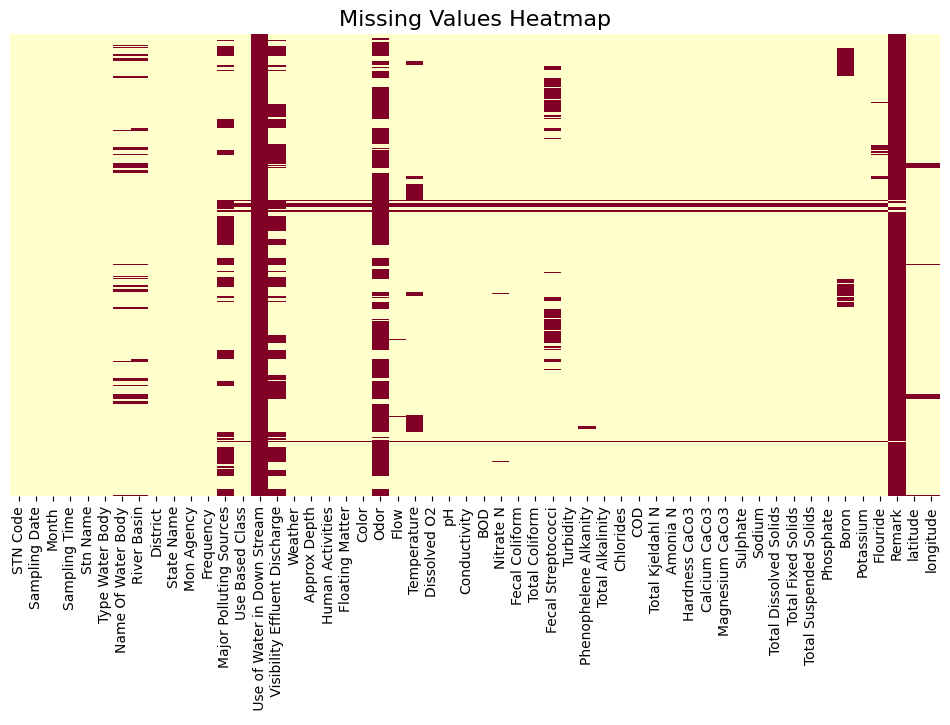

In [12]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))
# Use a better color map and add title
sns.heatmap(df.isnull(), cbar=False,cmap='YlOrRd', yticklabels=False)
# Add title
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

### What did you know about your dataset?

* The dataset contains 444 rows and 54 columns.

* This dataset focuses on water quality monitoring data collected from different water bodies in Maharashtra under the National Water Monitoring Programme. It includes detailed information about sampling locations, physicochemical parameters, biological indicators, and environmental conditions of water bodies.

* The dataset contains attributes such as station code, sampling date and time, district, river basin, temperature, pH, dissolved oxygen, BOD, COD, nitrate, fecal coliform, total coliform, conductivity, total dissolved solids, and many other water quality indicators.

* The dataset does not contain any duplicate values.

* The dataset contains multiple data types, including integers, floats, and object data types.

The dataset has many missing values in multiple columns such as:

Use of Water in Down Stream (444 null values),
Remark (436 null values),
Odor (327 null values),
Visibility Effluent Discharge (181 null values),
Major Polluting Sources (140 null values),
Fecal Streptococci (91 null values),
Boron (59 null values),
Temperature (50 null values),
River Basin (48 null values),
Name Of Water Body (44 null values)

Several important numerical columns like pH, BOD, Conductivity, Total Coliform, Fecal Coliform, and Dissolved O2 have 8 missing values each.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns

Index(['STN Code', 'Sampling Date', 'Month', 'Sampling Time', 'Stn Name',
       'Type Water Body', 'Name Of Water Body', 'River Basin', 'District',
       'State Name', 'Mon Agency', 'Frequency', 'Major Polluting Sources',
       'Use Based Class', ' Use of Water in Down Stream',
       ' Visibility Effluent Discharge', 'Weather', 'Approx Depth',
       'Human Activities', 'Floating Matter', 'Color', 'Odor', 'Flow',
       'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
       'Fecal Coliform', 'Total Coliform', 'Fecal Streptococci', 'Turbidity',
       'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD',
       'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3',
       'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids',
       'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron',
       'Potassium', 'Flouride', 'Remark', 'latitude', 'longitude'],
      dtype='object')

In [14]:
# Dataset Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
STN Code,444.0,2615.716216,1273.540858,11.0,2162.00,2668.5,2782.0000,5997.0
Use of Water in Down Stream,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flow,434.0,0.326498,1.027593,0.0,0.00,0.0,0.0000,8.0
Temperature,394.0,25.732234,3.186326,16.0,24.00,27.0,28.0000,32.0
pH,436.0,7.889037,0.417601,6.9,7.60,7.9,8.2000,9.7
Conductivity,436.0,3778.706422,9962.387086,44.0,183.00,363.0,728.0000,74240.0
BOD,436.0,7.933716,13.592014,1.8,3.20,4.1,8.0000,210.0
COD,436.0,40.817202,62.400566,8.0,12.00,16.0,28.0000,624.0
Amonia N,436.0,1.004083,2.001208,0.4,0.40,0.4,0.7025,24.6
Hardness CaCo3,436.0,527.914220,1248.619373,16.0,62.00,101.0,207.3000,7390.0


### Variables Description



**Key Attributes for Water Quality Classification**

**Dissolved O2**

* Measures oxygen available for aquatic life.
* Good quality water typically has DO > 5 mg/L.
* High DO is required for Class A water.
* Low DO indicates organic pollution and oxygen depletion.
* Strong inverse relationship with BOD.

**BOD (Biochemical Oxygen Demand)**

* Measures oxygen required by microorganisms to decompose organic matter.
* Clean water usually has BOD < 3 mg/L.
* Class A water typically requires very low BOD.
* High BOD directly indicates organic contamination.


**COD (Chemical Oxygen Demand)**

* Measures total organic matter in water.
* Class A water typically has COD < 10 mg/L.
* COD is usually higher than BOD.
* Captures chemical pollutants not measured by BOD.


**pH**

* Measures acidity or alkalinity of water.
* Safe range: 6.5 to 8.5.
* Values outside this range may cause toxicity.
* Affects solubility of metals and biological activity.

**Total Coliform**

* Indicator of bacterial contamination.
* Safe drinking water typically has < 50 MPN/100 mL.
* High values indicate fecal pollution risk.
* Critical parameter for Class A classification.


Fecal Coliform

* Indicates contamination from human or animal waste.
* Safe limit typically < 10 MPN/100 mL.
* Important public health risk indicator.

Nitrate Nitrogen (NO3-N)

* Agricultural runoff indicator.
* Safe level typically < 10 mg/L.
* High levels cause eutrophication and oxygen depletion.

Total Dissolved Solids

* Measures mineral content in water.
* Acceptable level generally < 500 mg/L.
* High TDS indicates salinity and hardness.

Conductivity

* Measures dissolved ions in water.
* Acceptable range typically < 1000 µS/cm.
* Strongly correlated with TDS.

Turbidity

* Measures cloudiness of water.
* Safe level generally < 5 NTU.
* High turbidity indicates suspended particles or algae.

Temperature

* Typical range: 10–30°C.
* Higher temperature reduces dissolved oxygen.
* Influences biological and chemical processes.


**Additional Important Attributes for Advanced Analysis**

Ammonia N

* Indicates sewage contamination.
* Toxic at high concentrations.
* Important for detecting fresh pollution.

Total Kjeldahl Nitrogen

* Measures organic nitrogen and ammonia.
* Contributes to nutrient pollution.

Phosphate

* Major nutrient for algal growth.
* High levels lead to eutrophication.

Hardness CaCO3

* Measures total hardness due to calcium and magnesium.
* Affects irrigation and industrial suitability.

Calcium CaCO3

* Indicates calcium concentration.
* Contributes to water hardness.

Magnesium CaCO3

* Indicates magnesium concentration.
* Also contributes to hardness.

Chlorides

* Indicator of salinity.
* High values may indicate industrial discharge.

Sulphate

* Naturally occurring or from industrial waste.
* High levels affect water usability.

Sodium

* High sodium affects irrigation suitability.
* Important for agricultural water use.

Potassium

* Naturally occurring mineral.
* Elevated levels may indicate contamination.

Boron

* Important for irrigation quality assessment.
* High boron is toxic to plants.

Fluoride

* Low concentration beneficial for teeth.
* High concentration harmful.

Total Suspended Solids

* Measures suspended particles in water.
* High values indicate sediment pollution.

Total Fixed Solids

* Represents inorganic solid content after evaporation.

Total Alkalinity

* Indicates buffering capacity of water.
* Helps resist sudden pH changes.

Phenolphthalein Alkalinity

* Measures specific alkalinity component.
* Important for chemical balance analysis.

Fecal Streptococci

* Indicator of fecal contamination from warm-blooded animals.

Flow

* Affects dilution of pollutants.
* Low flow increases contamination concentration.


## 3. ***Data Wrangling***

### Data Wrangling Code

In [94]:
# Create a copy of the original DataFrame
df1 = df.copy()
#  checking dataset info
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   STN Code                        444 non-null    int64  
 1   Sampling Date                   444 non-null    object 
 2   Month                           444 non-null    object 
 3   Sampling Time                   444 non-null    object 
 4   Stn Name                        444 non-null    object 
 5   Type Water Body                 444 non-null    object 
 6   Name Of Water Body              400 non-null    object 
 7   River Basin                     396 non-null    object 
 8   District                        444 non-null    object 
 9   State Name                      444 non-null    object 
 10  Mon Agency                      444 non-null    object 
 11  Frequency                       444 non-null    object 
 12  Major Polluting Sources         304 

In [16]:
# Inspecting null/missing value count and percentage
null_df = pd.DataFrame({
    'percentage_null_values': round(df1.isna().sum() * 100 / len(df1), 2),'missing_value_count': df1.isna().sum()
}).sort_values(by='percentage_null_values', ascending=False)

null_df


,percentage_null_values,missing_value_count
Use of Water in Down Stream,100.00,444
Remark,98.20,436
Odor,73.65,327
Visibility Effluent Discharge,40.77,181
Major Polluting Sources,31.53,140
Fecal Streptococci,20.50,91
Boron,13.29,59
Temperature,11.26,50
River Basin,10.81,48
Name Of Water Body,9.91,44


In [17]:
df1.columns

Index(['STN Code', 'Sampling Date', 'Month', 'Sampling Time', 'Stn Name',
       'Type Water Body', 'Name Of Water Body', 'River Basin', 'District',
       'State Name', 'Mon Agency', 'Frequency', 'Major Polluting Sources',
       'Use Based Class', ' Use of Water in Down Stream',
       ' Visibility Effluent Discharge', 'Weather', 'Approx Depth',
       'Human Activities', 'Floating Matter', 'Color', 'Odor', 'Flow',
       'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
       'Fecal Coliform', 'Total Coliform', 'Fecal Streptococci', 'Turbidity',
       'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD',
       'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3',
       'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids',
       'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron',
       'Potassium', 'Flouride', 'Remark', 'latitude', 'longitude'],
      dtype='object')

In [95]:
cols_to_drop = [
    ' Use of Water in Down Stream',
    'Remark',
    'Odor'
]  # Columns  drop that above 60% missing values

df1 = df1.drop(columns=cols_to_drop)

print("New Shape:", df1.shape)

New Shape: (444, 51)


In [19]:
# inspecting dataset after data wrangling
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   STN Code                        444 non-null    int64  
 1   Sampling Date                   444 non-null    object 
 2   Month                           444 non-null    object 
 3   Sampling Time                   444 non-null    object 
 4   Stn Name                        444 non-null    object 
 5   Type Water Body                 444 non-null    object 
 6   Name Of Water Body              400 non-null    object 
 7   River Basin                     396 non-null    object 
 8   District                        444 non-null    object 
 9   State Name                      444 non-null    object 
 10  Mon Agency                      444 non-null    object 
 11  Frequency                       444 non-null    object 
 12  Major Polluting Sources         304 

#### Convert columns into appropriate datatype

In [96]:
# Convert date columns to datetime type
df1['Sampling Date'] = pd.to_datetime(df1['Sampling Date'], errors='coerce', dayfirst=True, infer_datetime_format=True)

In [97]:
print(df1['Sampling Date'].dtype)
print(df1['Sampling Date'].isnull().sum())

datetime64[ns]
0


In [98]:
# Remove (BDL) text
df1 = df1.replace(r'\(BDL\)', '', regex=True)

# Now convert important numeric columns
numeric_cols = [
    'Dissolved O2',
    'BOD',
    'COD',
    'pH',
    'Conductivity',
    'Nitrate N',
    'Fecal Coliform',
    'Total Coliform','Fecal Streptococci','Turbidity','Phenophelene Alkanity','Total Alkalinity','Chlorides','Total Kjeldahl N','Sulphate','Sodium','Total Suspended Solids',
    'Turbidity','Phosphate','Boron','Potassium','Flouride',
    'Temperature',
    'Total Dissolved Solids'
]

for col in numeric_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   STN Code                        444 non-null    int64         
 1   Sampling Date                   444 non-null    datetime64[ns]
 2   Month                           444 non-null    object        
 3   Sampling Time                   444 non-null    object        
 4   Stn Name                        444 non-null    object        
 5   Type Water Body                 444 non-null    object        
 6   Name Of Water Body              400 non-null    object        
 7   River Basin                     396 non-null    object        
 8   District                        444 non-null    object        
 9   State Name                      444 non-null    object        
 10  Mon Agency                      444 non-null    object        
 11  Freque

### What all manipulations have you done and insights you found?



Data Manipulations:

1. Created a copy of the original dataset for data wrangling to avoid modifying the raw data.


3. Dropped the  Use of Water in Down Stream,Remark,Odor column due to extremely high missing values.

4. Some numeric values contained BDL(Below Detection Limit) annotation.
Instead of replacing them with zero, I extracted the numeric portion and converted them to float to preserve measurement information.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [99]:
#creating copy
new_df = df1.copy()

In [27]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   STN Code                        444 non-null    int64         
 1   Sampling Date                   444 non-null    datetime64[ns]
 2   Month                           444 non-null    object        
 3   Sampling Time                   444 non-null    object        
 4   Stn Name                        444 non-null    object        
 5   Type Water Body                 444 non-null    object        
 6   Name Of Water Body              400 non-null    object        
 7   River Basin                     396 non-null    object        
 8   District                        444 non-null    object        
 9   State Name                      444 non-null    object        
 10  Mon Agency                      444 non-null    object        
 11  Freque

In [28]:
#storing numerical feature in separate variable
num_feature = new_df.select_dtypes(exclude='object')    #Return a subset of the DataFrame’s columns based on the column dtypes
print(f'Numerical feature : {num_feature.columns.to_list()}')

Numerical feature : ['STN Code', 'Sampling Date', 'Flow', 'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform', 'Fecal Streptococci', 'Turbidity', 'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD', 'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3', 'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids', 'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium', 'Flouride']


In [29]:
#storing categorial feature in separate variable
cat_feature = new_df.loc[:,  ~new_df.columns.isin(num_feature.columns.to_list())] #Pandas isin() method is used to filter data frames using boolean value true of false
print(f'Categorical feature : {cat_feature.columns.to_list()}')               #Tilde sign (~)works as a negation operator i.e reverse true to false and false to true

Categorical feature : ['Month', 'Sampling Time', 'Stn Name', 'Type Water Body', 'Name Of Water Body', 'River Basin', 'District', 'State Name', 'Mon Agency', 'Frequency', 'Major Polluting Sources', 'Use Based Class', ' Visibility Effluent Discharge', 'Weather', 'Approx Depth', 'Human Activities', 'Floating Matter', 'Color', 'latitude', 'longitude']


### **Univariate Analysis**

#### **Count Plots Of Specified Variables**

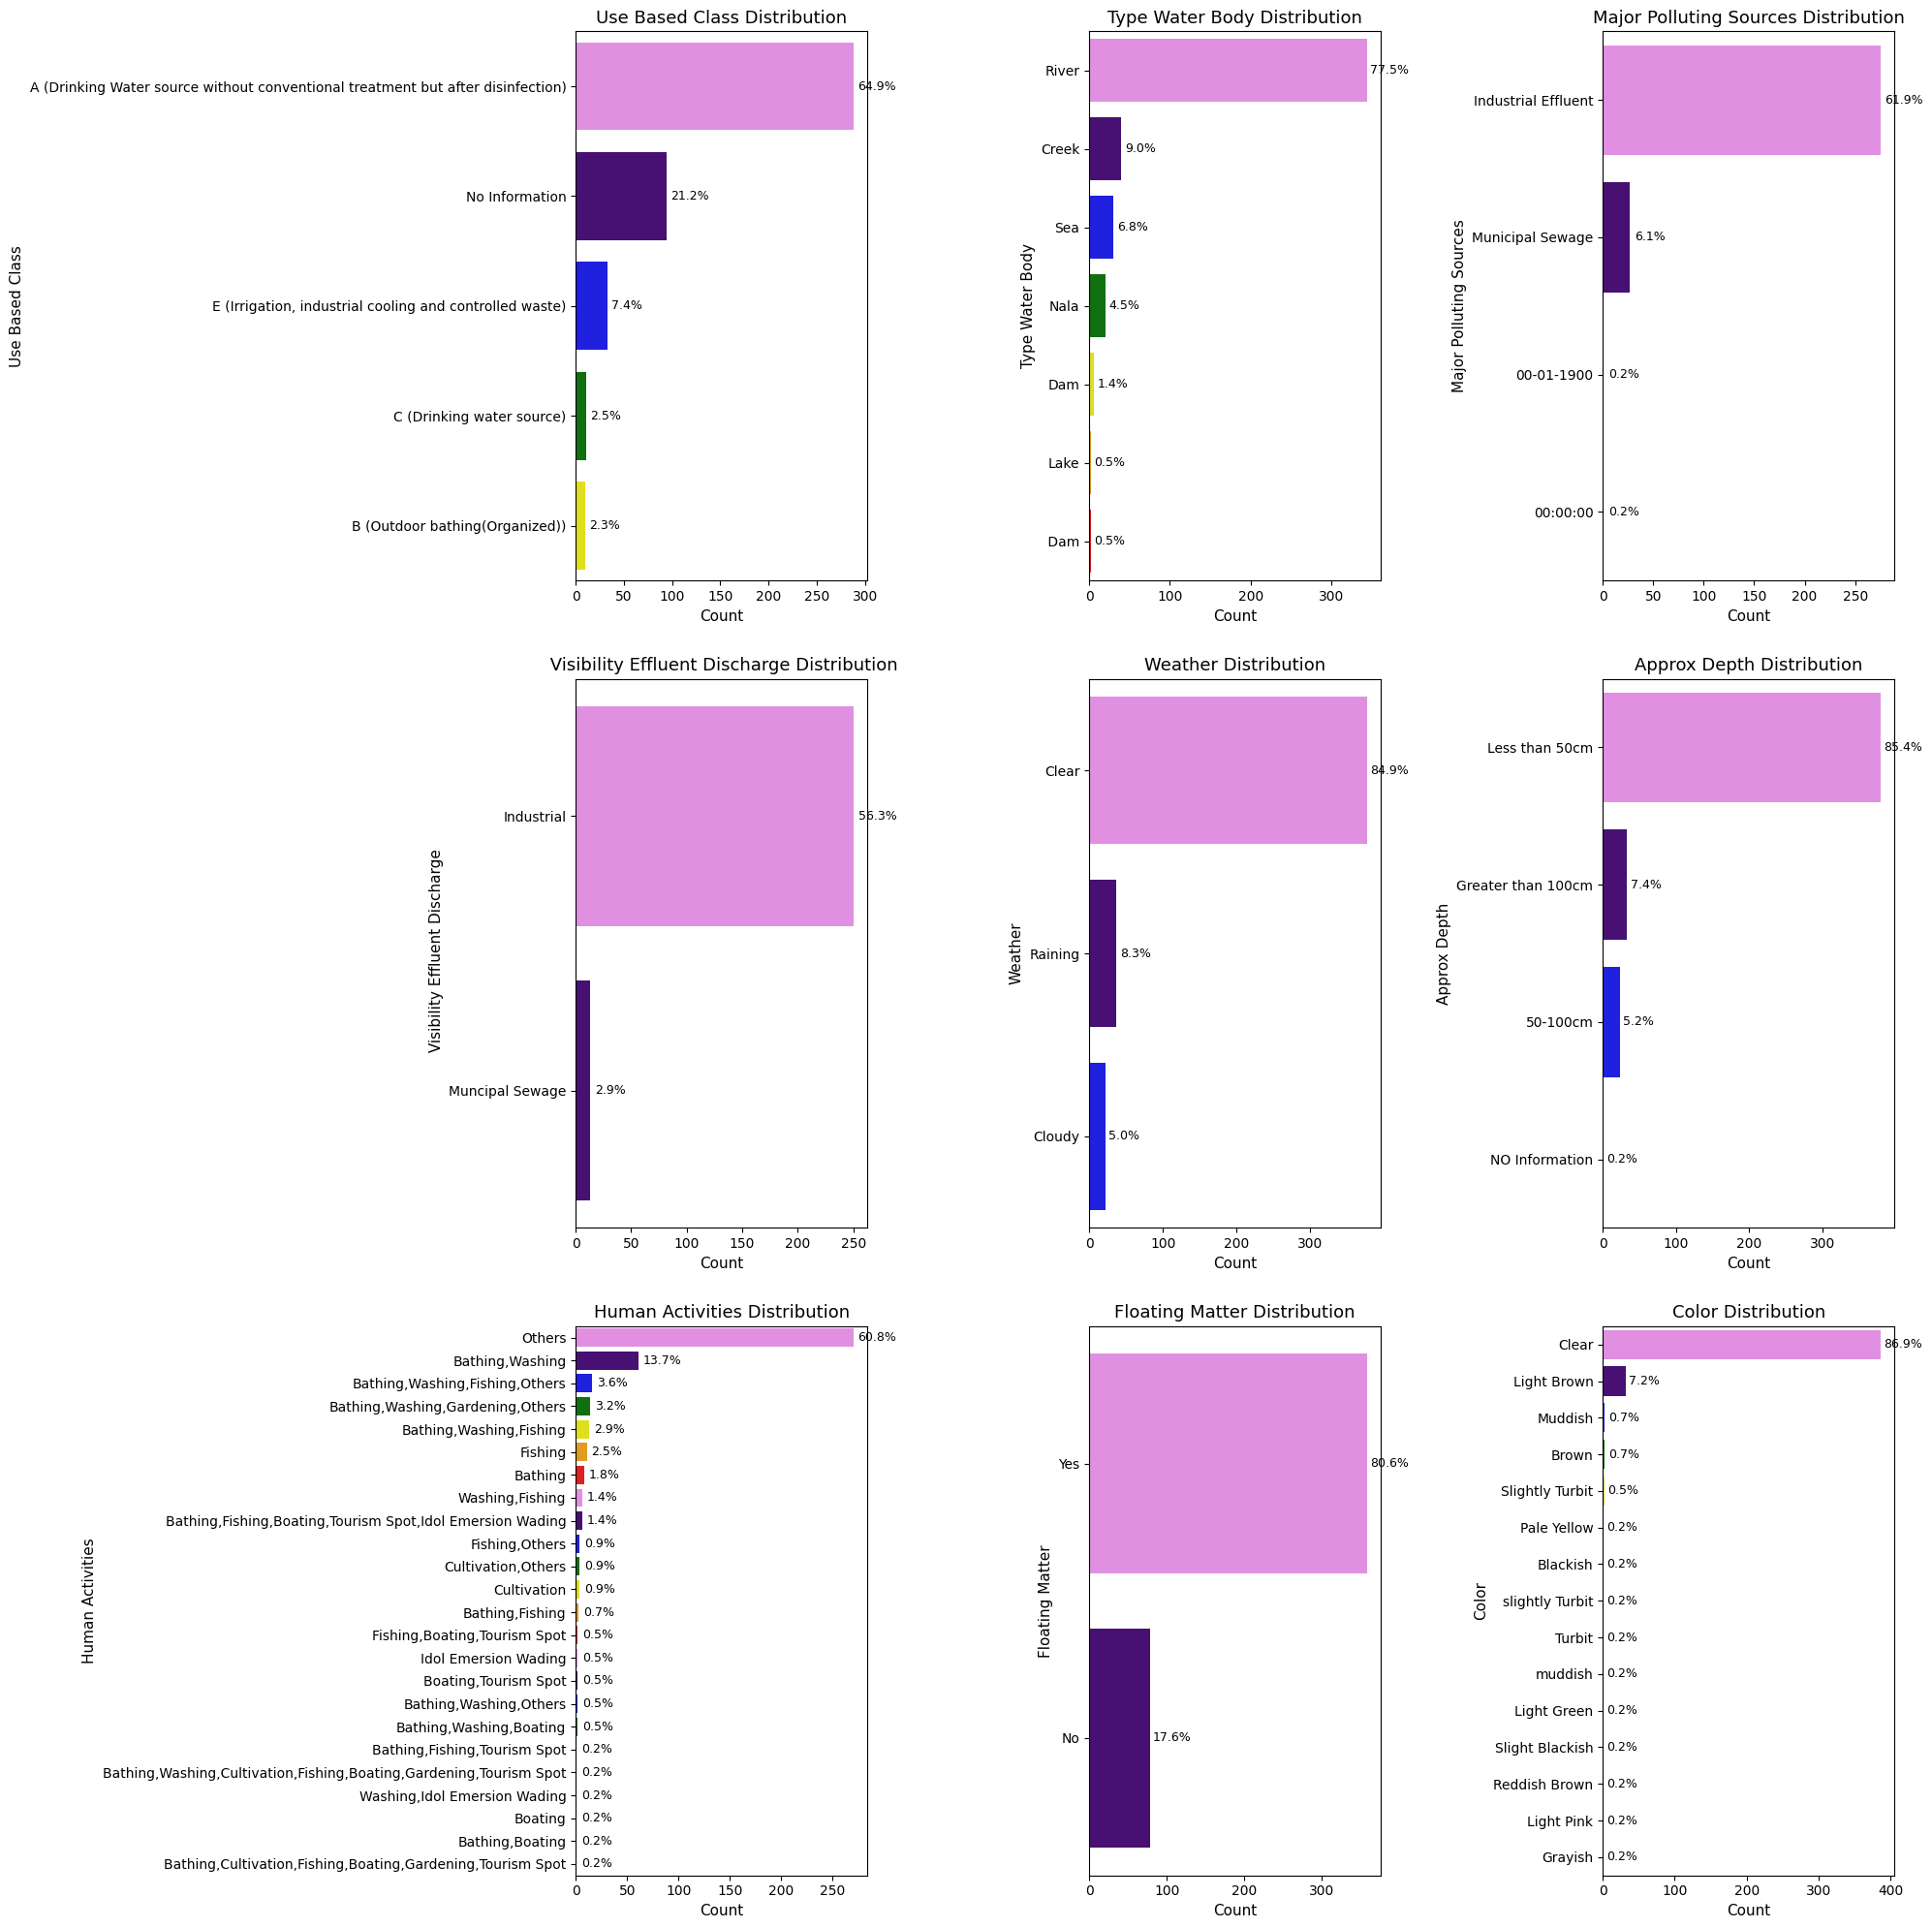

In [30]:
# custom color palette
custom_colors = ['violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red']

# columns to plot
columns_to_plot = ['Use Based Class','Type Water Body', "Major Polluting Sources", " Visibility Effluent Discharge", 'Weather',
                   'Approx Depth', 'Human Activities', 'Floating Matter', 'Color'] # Removed 'Odor'
# create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20)) # Changed to 3x3 grid
axes = axes.flatten()
total = len(new_df)  # total number of records
for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    order = new_df[col].value_counts().index  # ordering by frequency

    # dynamically limit custom_colors to number of unique values in column
    num_categories = new_df[col].nunique()
    color_palette = custom_colors[:num_categories]  # slice custom palette

    # plot
    sns.countplot(data=new_df, y=col, ax=ax, palette=color_palette, order=order)
    # title and labels
    ax.set_title(f'{col} Distribution', fontsize=13)
    ax.set_ylabel(col, fontsize=11)
    ax.set_xlabel('Count', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    # add percentage labels
    for p in ax.patches:
        width = p.get_width()
        percentage = 100 * width / total
        ax.text(width + total * 0.01, p.get_y() + p.get_height() / 2,
                f'{percentage:.1f}%', va='center', fontsize=9, color='black')
# spacing
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.show()

#####  insight(s) found from the chart is below

 Insights from Categorical Distribution Charts

1. Use Based Class Distribution

* Majority of samples belong to **Class A (Drinking water source after disinfection)**, around 65%.
* Around 21% of records have **No Information**, which indicates missing or undefined classification.
* Very small proportion belongs to **Class B and Class C** (around 2–3% each).
* Around 7% belong to **Class E**, indicating limited severely polluted samples.
* The dataset is **highly imbalanced**, dominated by Class A.

 2. Type of Water Body Distribution

* Most samples are collected from **Rivers (~77%)**.
* Very few samples from lakes, dams, and other water bodies.
* The dataset is river-dominated, so model insights will mostly reflect river conditions.

3. Major Polluting Sources

* **Industrial effluent (~62%)** is the dominant pollution source.
* Municipal sewage contributes only a small percentage (~6%).
* Indicates industrial discharge is a major environmental concern.

4. Visibility of Effluent Discharge

* More than half of the locations show **visible industrial discharge (~56%)**.
* Very small percentage shows municipal discharge.
* Suggests strong industrial impact in monitored areas.

5. Weather Distribution

* Majority of samples collected in **clear weather (~85%)**.
* Few samples collected during rain (~8%).
* Seasonal variation impact may be limited in this dataset.

6. Approx Depth Distribution

* Around **85% of samples are from shallow water (<50 cm)**.
* Very few deep water samples.
* This may affect temperature and dissolved oxygen variation.

7. Human Activities

* Majority fall under **“Others” category (~61%)**, meaning mixed or unclassified activities.
* Bathing and washing are common activities.
* Indicates significant human interaction with water bodies.
 8. Floating Matter

* Around **80% of samples show floating matter present**.
* This indicates visible surface pollution in most water bodies.

 9. Color Distribution

* Around **87% of samples are clear**.
* Very small proportion shows turbidity or discoloration.
* Physically, water appears clean in most cases.


 Overall Key Insight

* Dataset is heavily dominated by Class A water.
* Industrial effluent is the primary pollution source.
* Most samples are shallow river samples.
* Physical appearance (color) is mostly clear, but floating matter is frequently present.
* There is potential class imbalance problem for modeling.


#### PH column distribution

<Axes: xlabel='pH', ylabel='Density'>

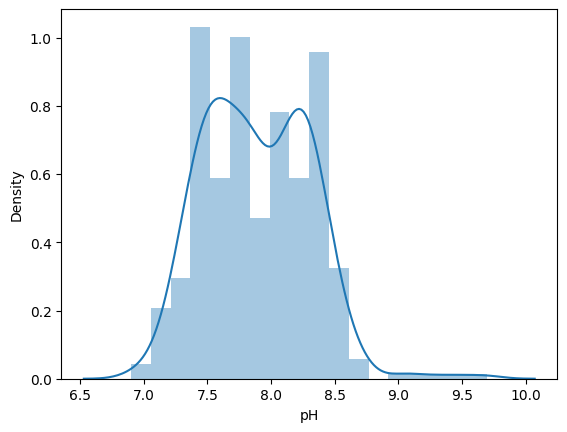

In [31]:
sns.distplot(new_df['pH'])

This Ph column distribution showed that ph value in all dataset water samples in mostly safe range

#### Numeric columns distribution

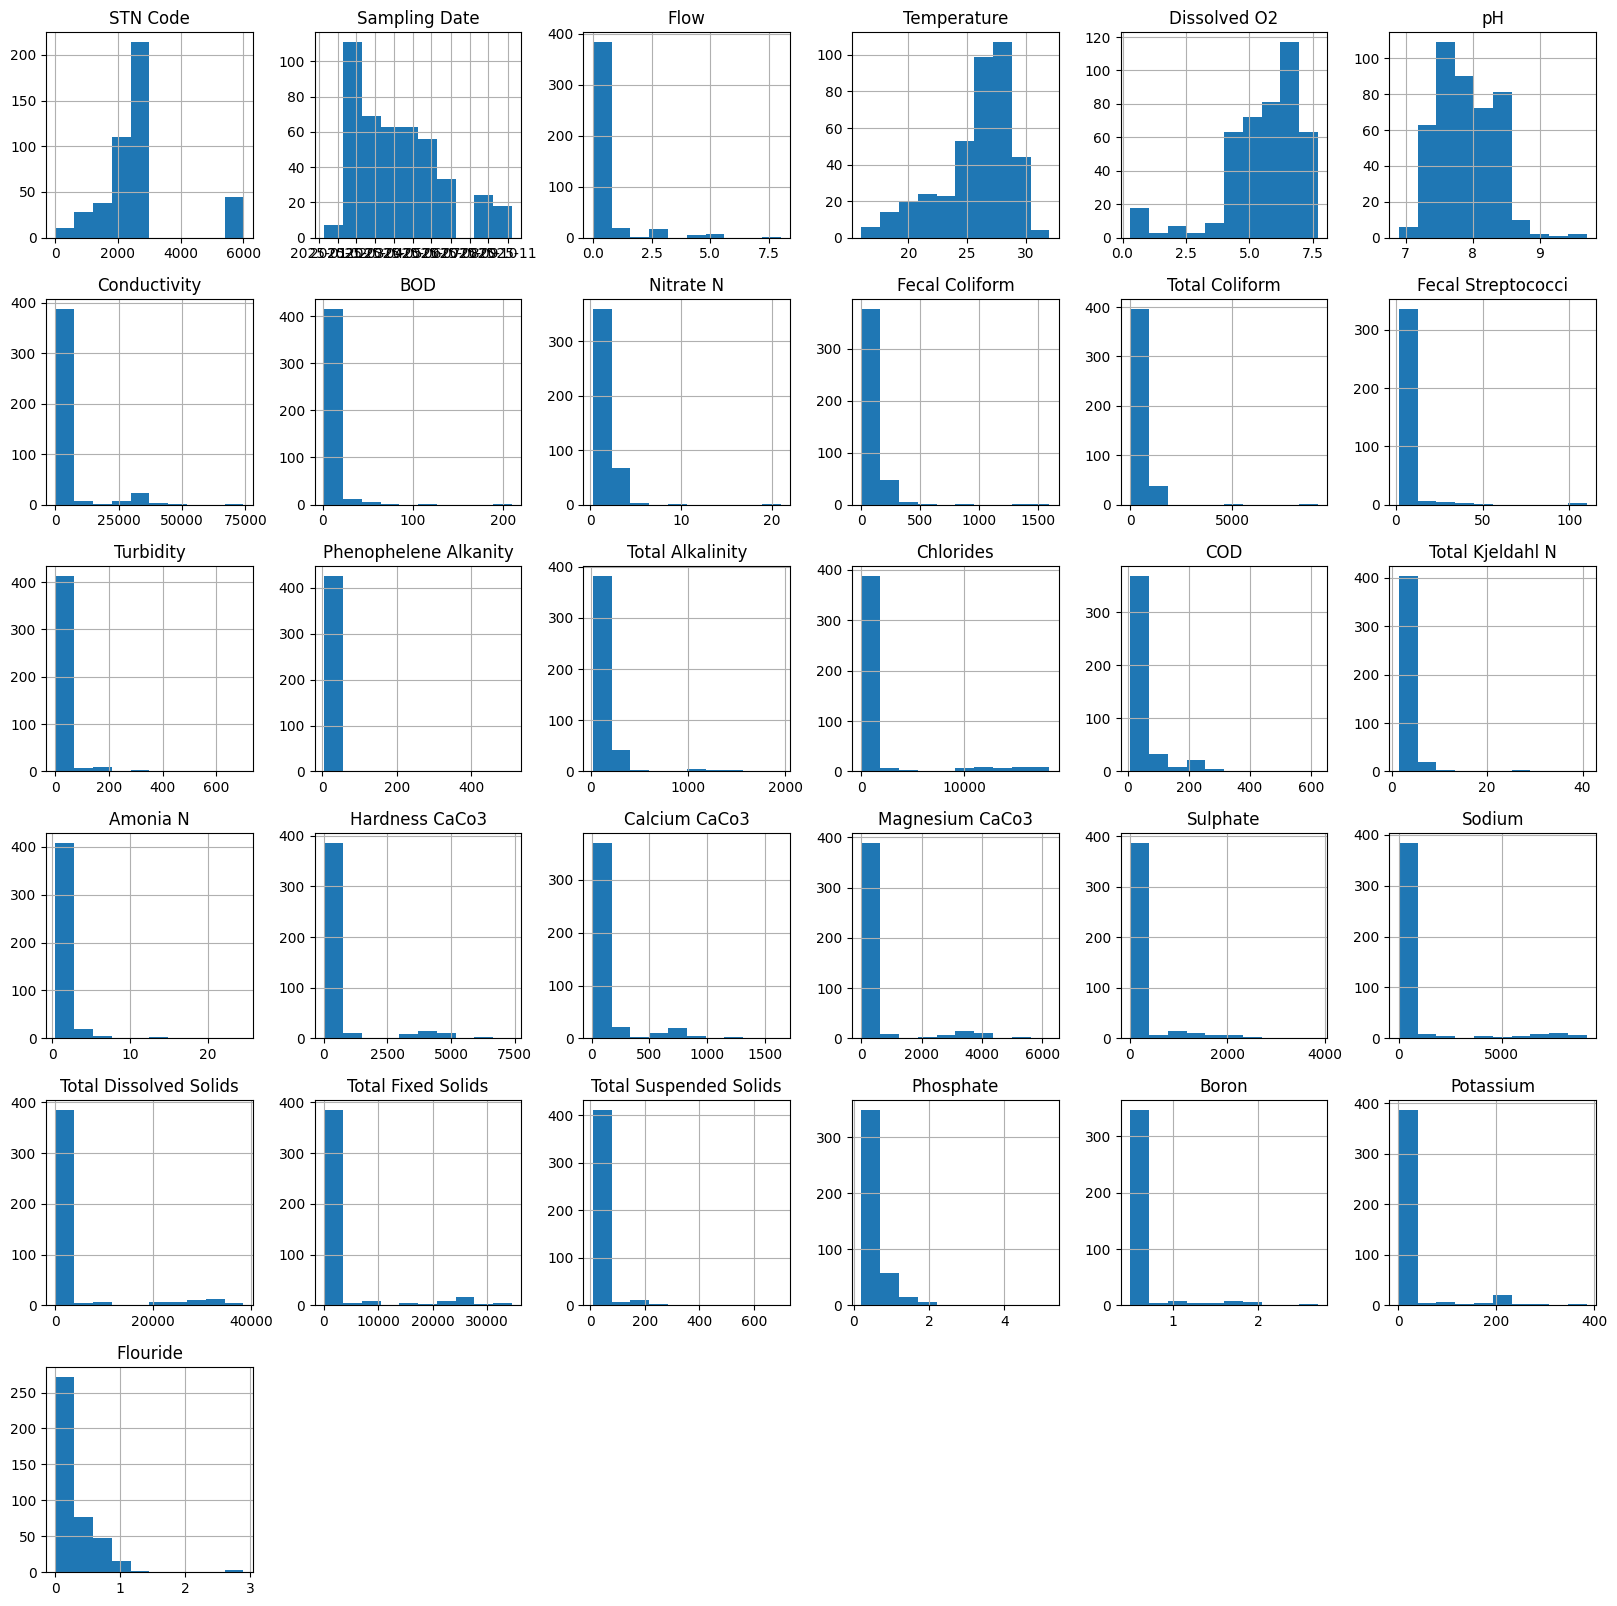

In [32]:
new_df.hist(figsize=(20,20))
plt.show()

Most numerical features are highly right-skewed with extreme outliers.
This suggests potential need for log transformation before model building.

### **Bivariate Analysis**

#### Boxplot and Barplot for target variable(based class) vs important numeric variables

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bivariate(feature):

    plt.figure(figsize=(14,5))

    # ---- Boxplot ----
    plt.subplot(1,2,1)
    sns.boxplot(x='Use Based Class', y=feature, data=new_df)
    plt.title(f'{feature} vs Water Class (Boxplot)')
    plt.xticks(rotation=90)

    # ---- Mean Barplot ----
    plt.subplot(1,2,2)
    median_df = new_df.groupby('Use Based Class')[feature].median().reset_index()
    sns.barplot(x='Use Based Class', y=feature, data=median_df)
    plt.title(f'Average {feature} by Water Class')
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

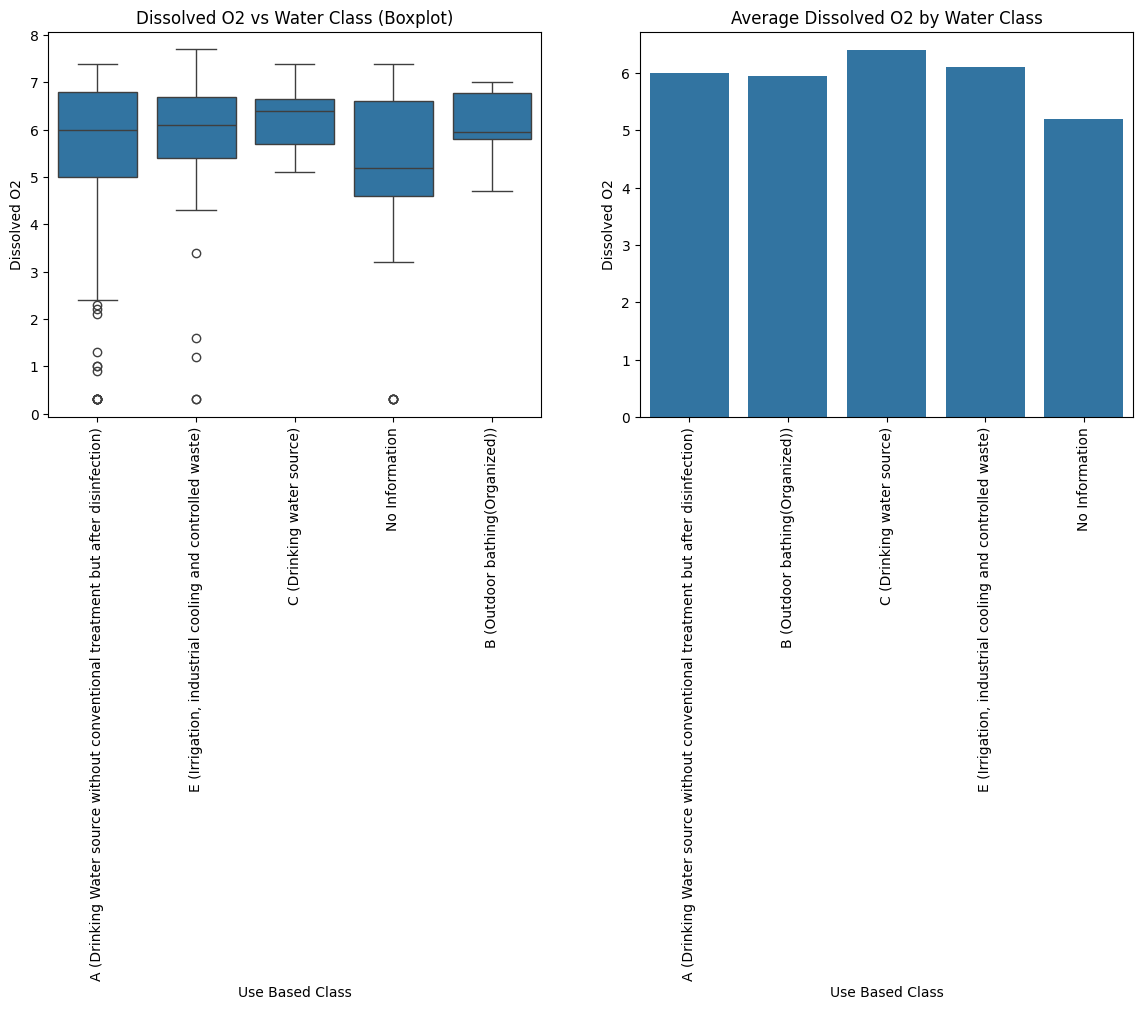

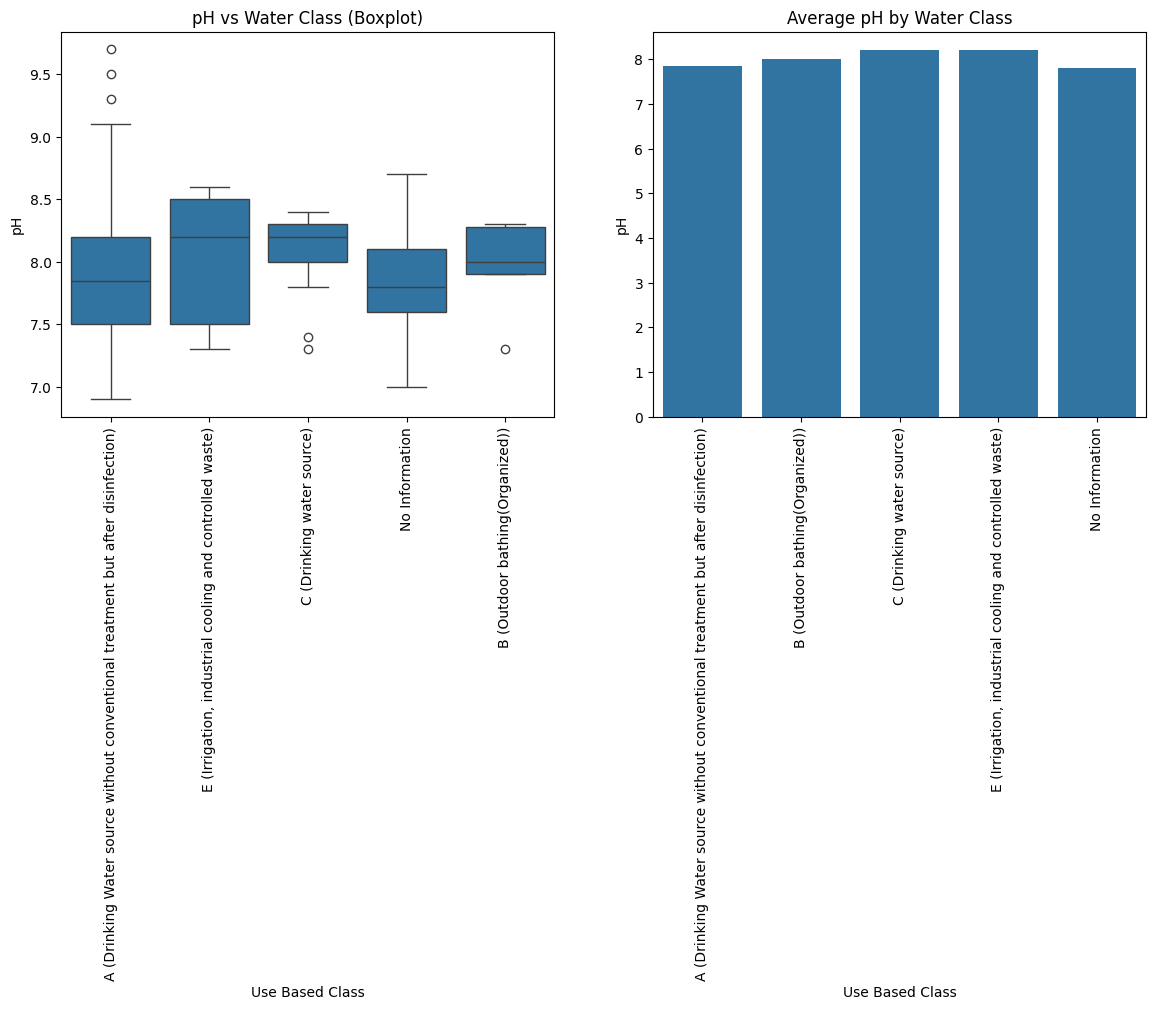

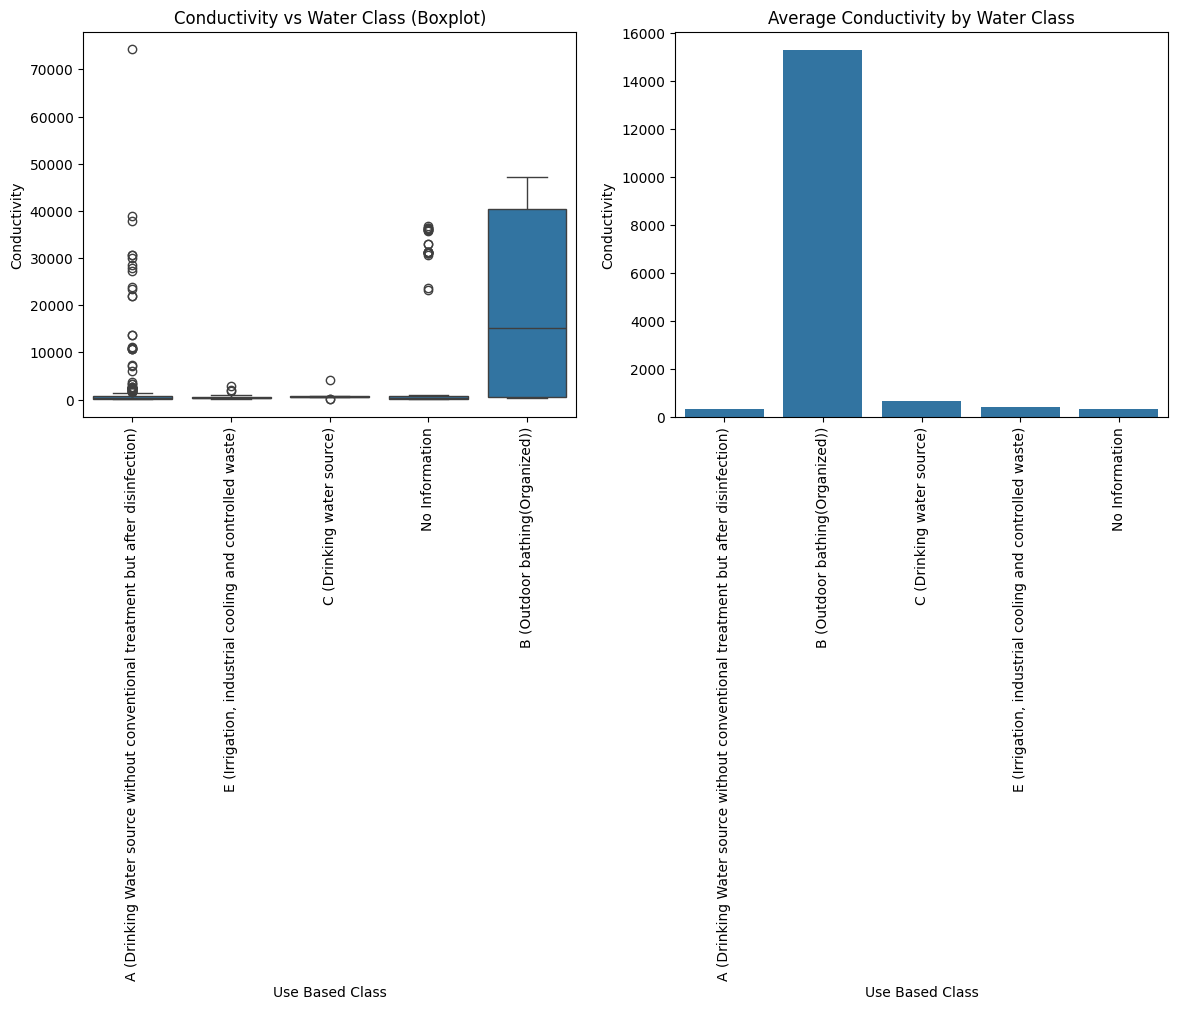

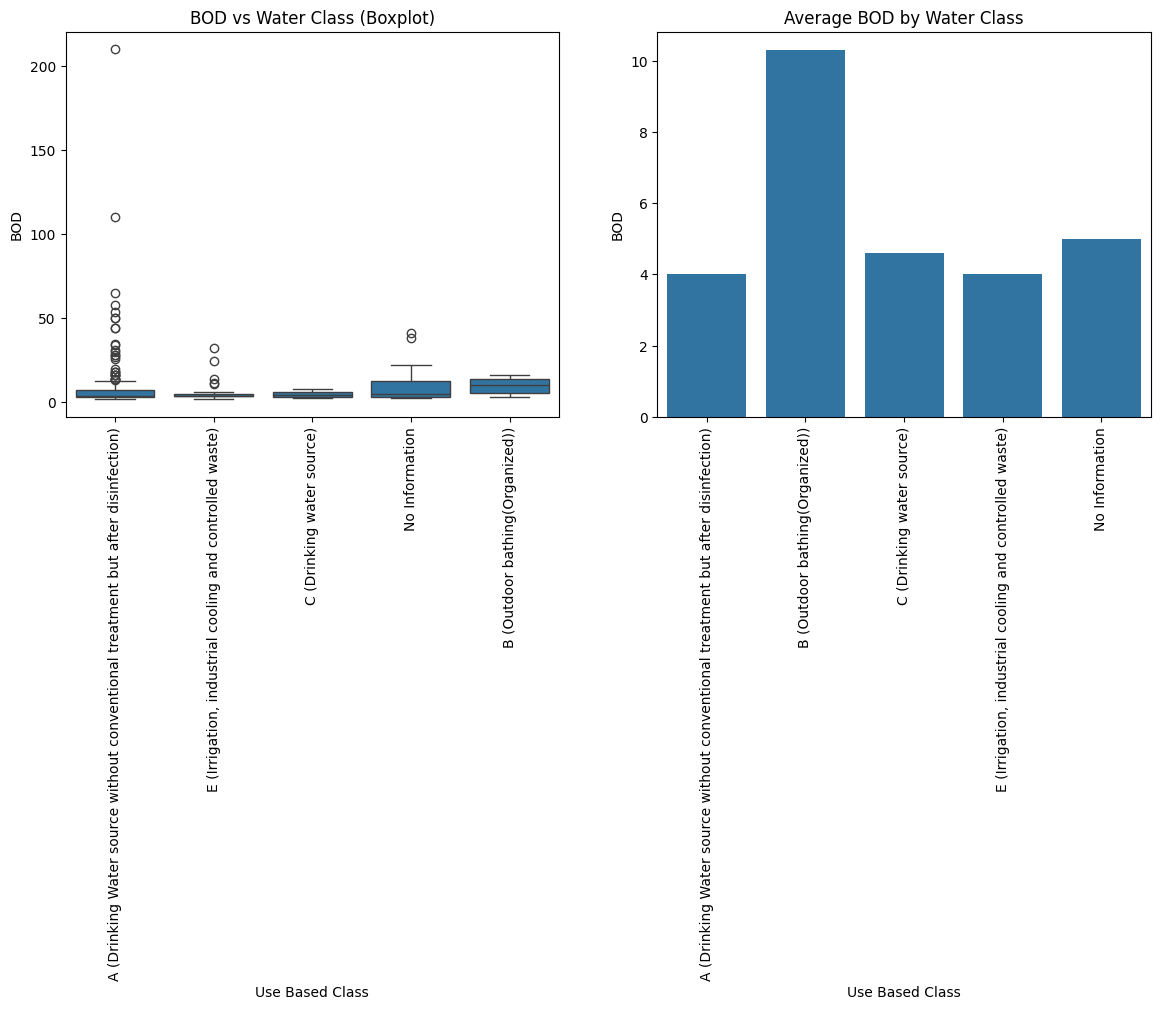

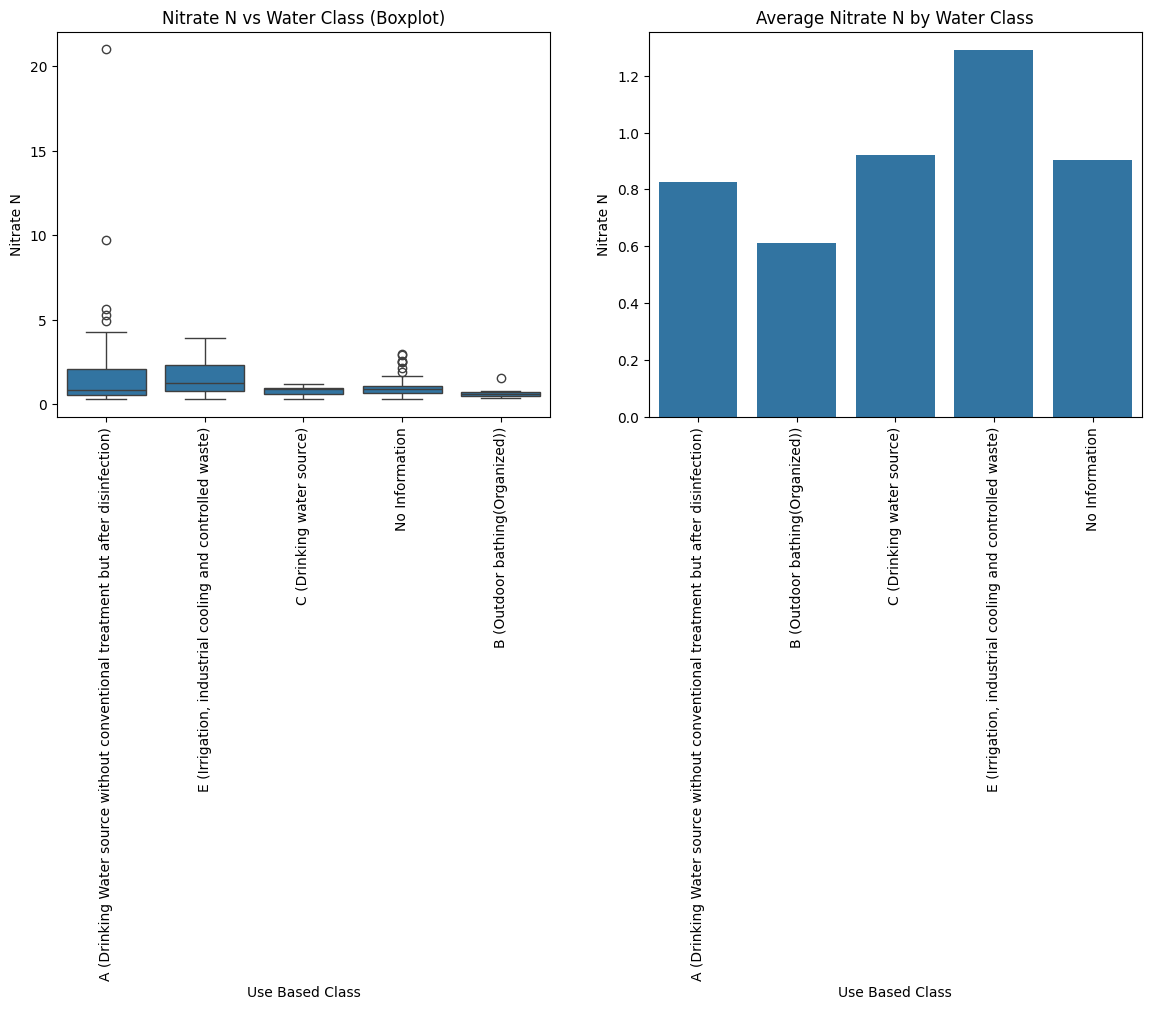

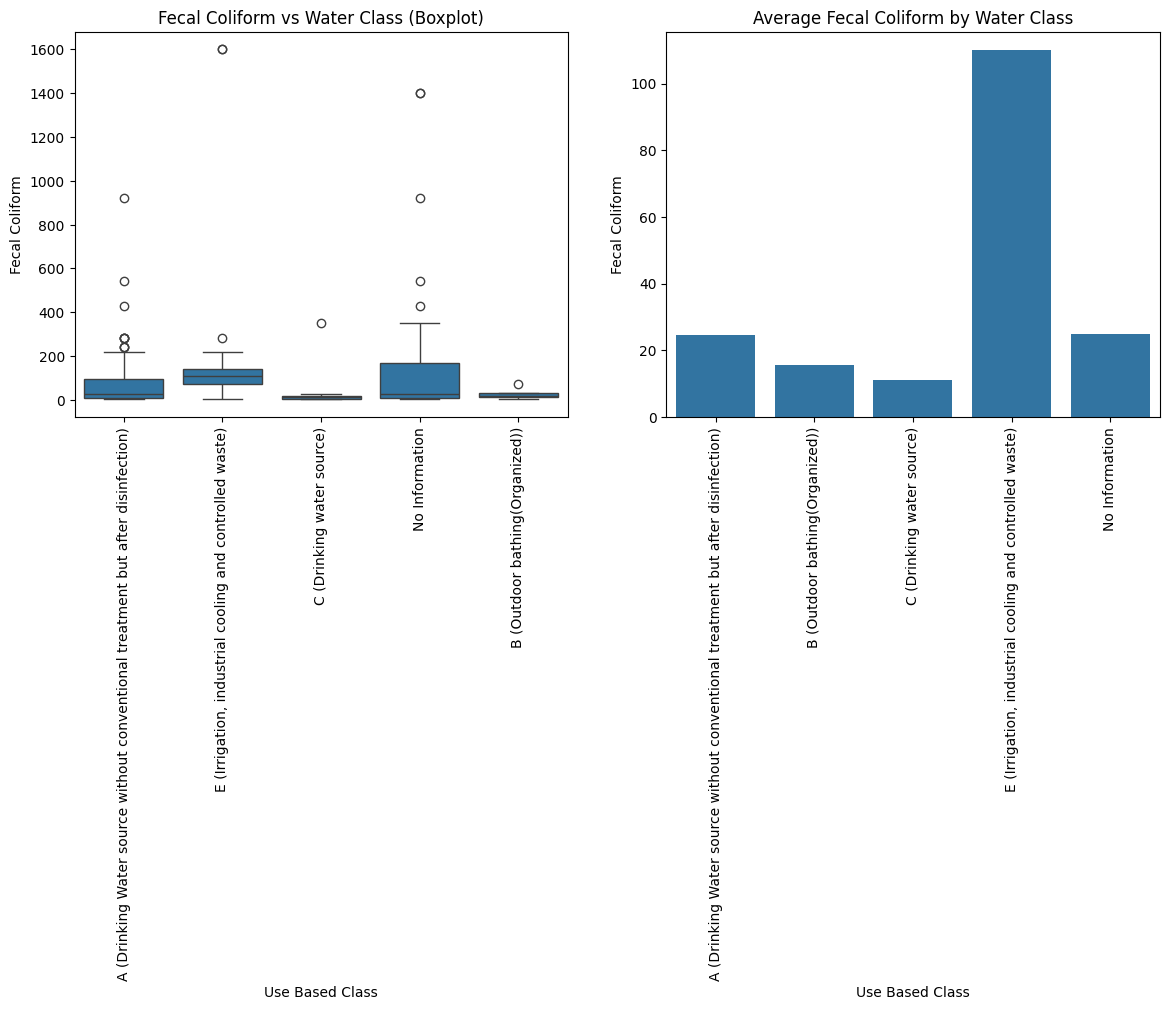

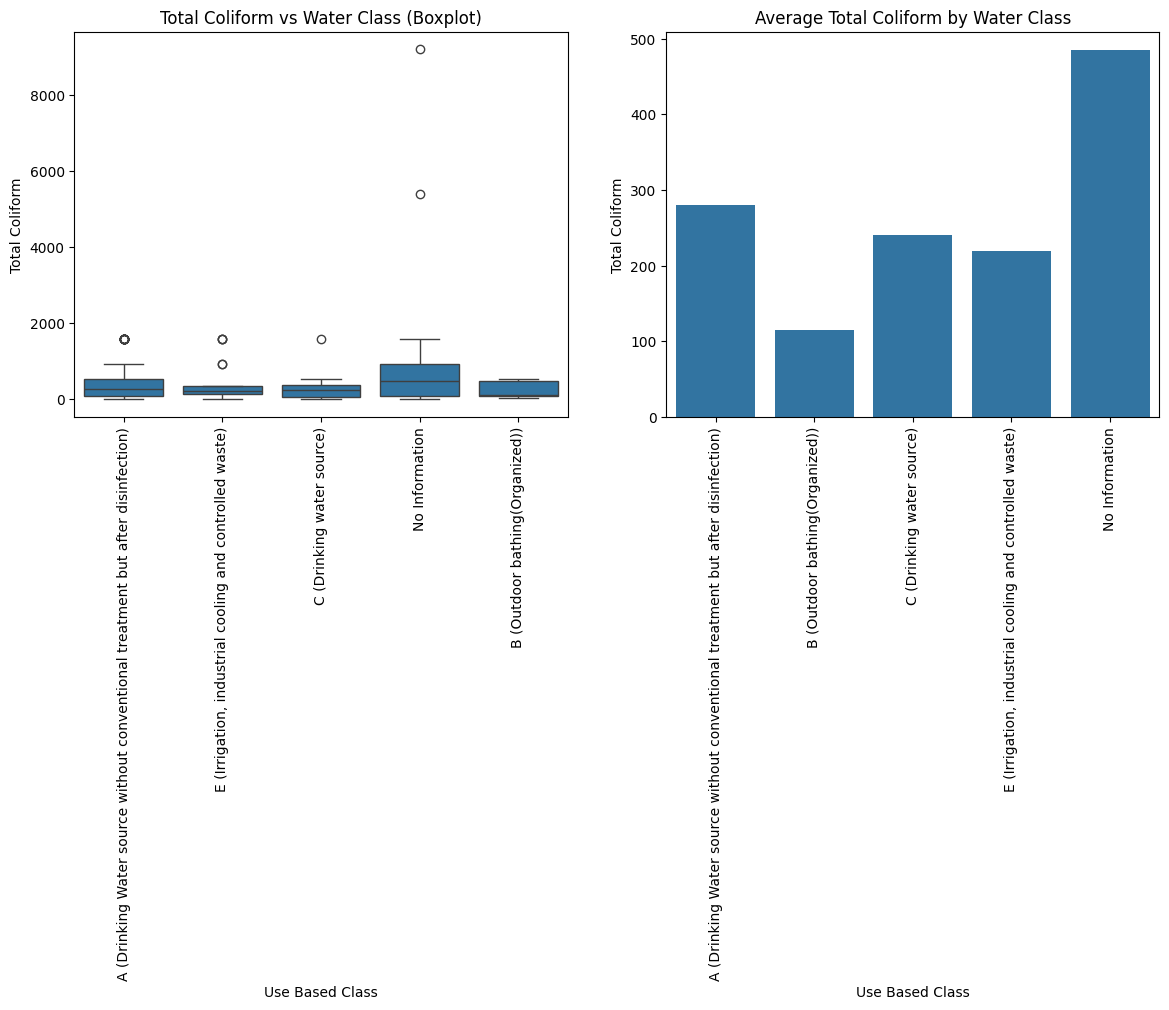

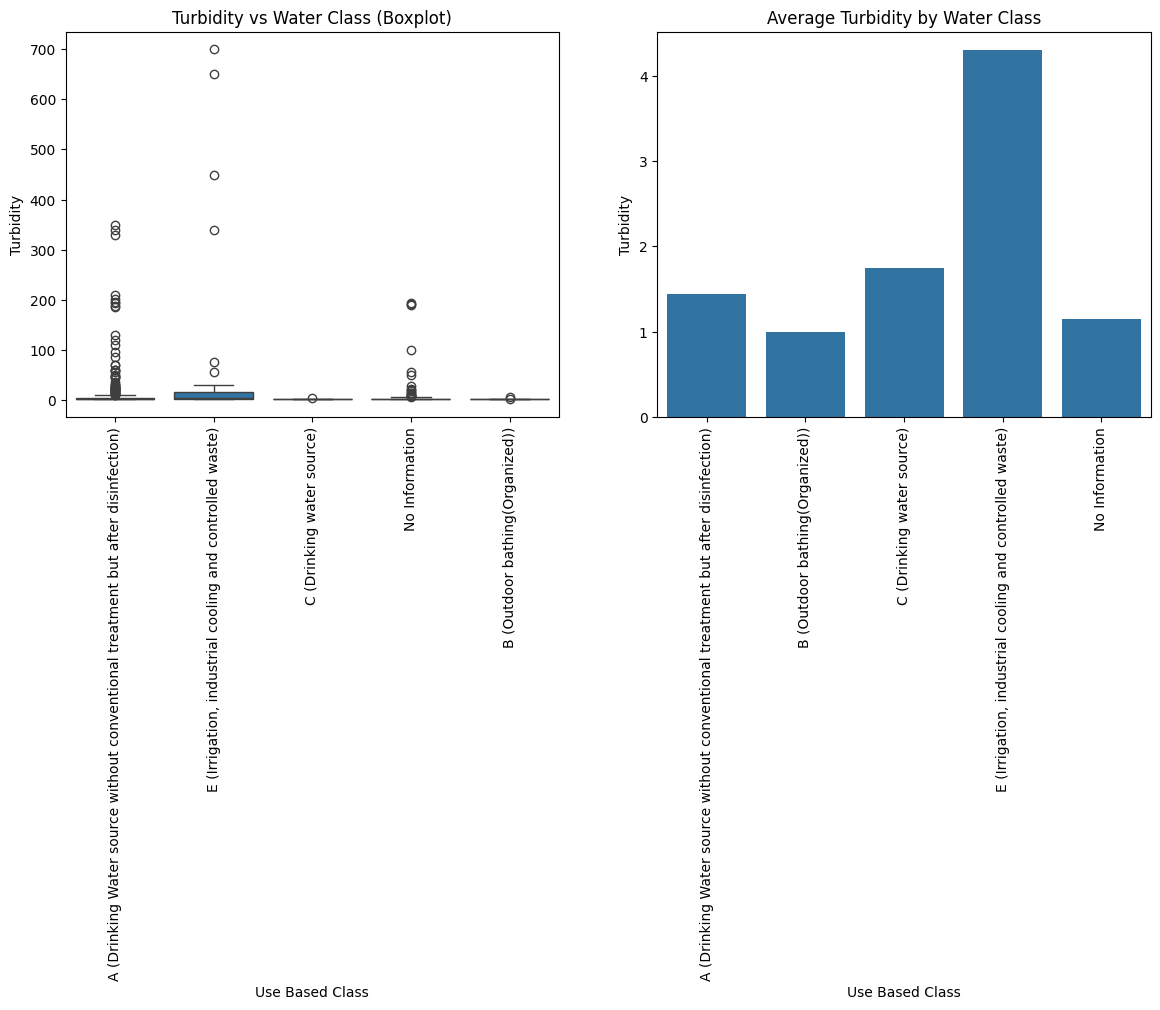

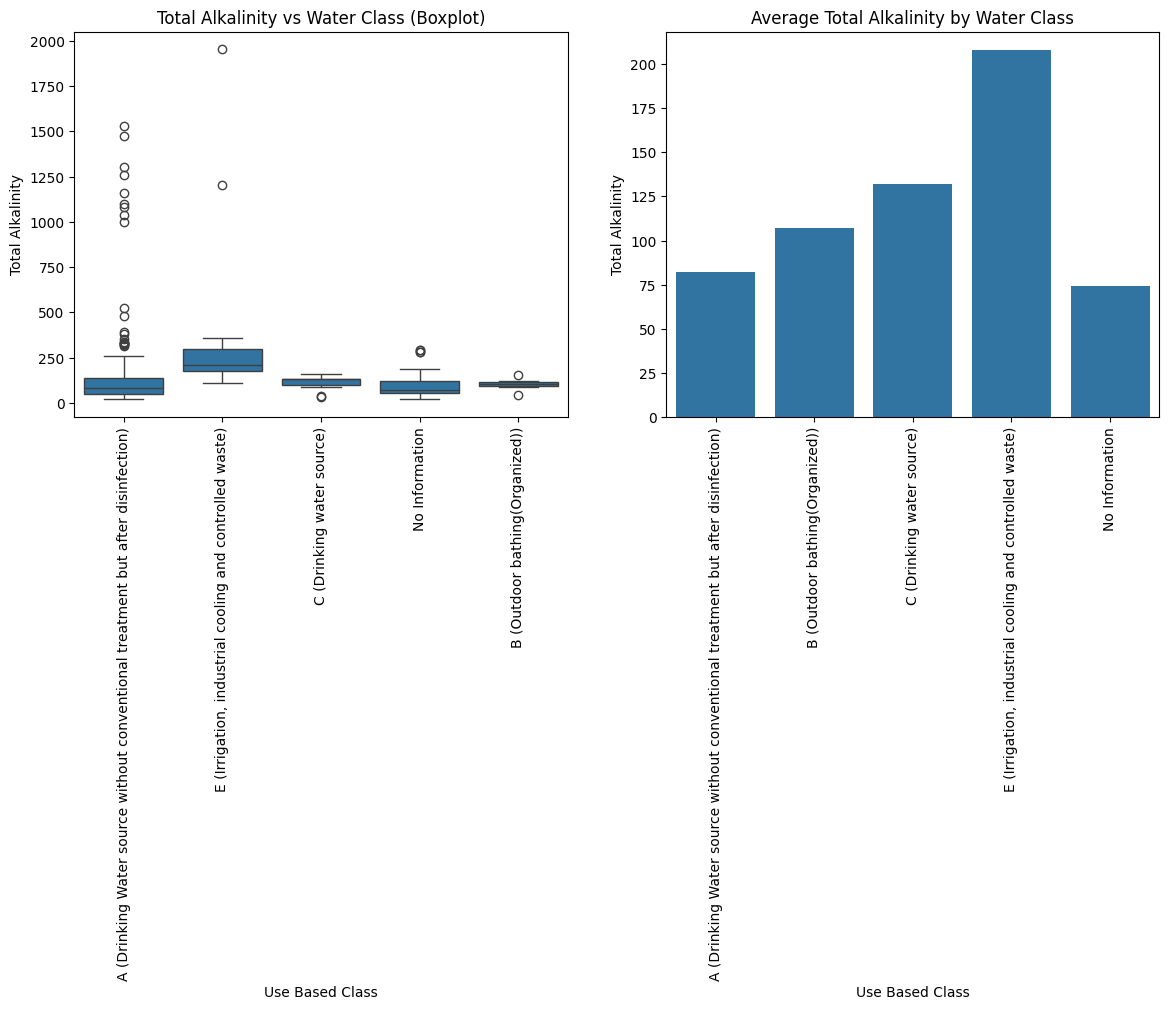

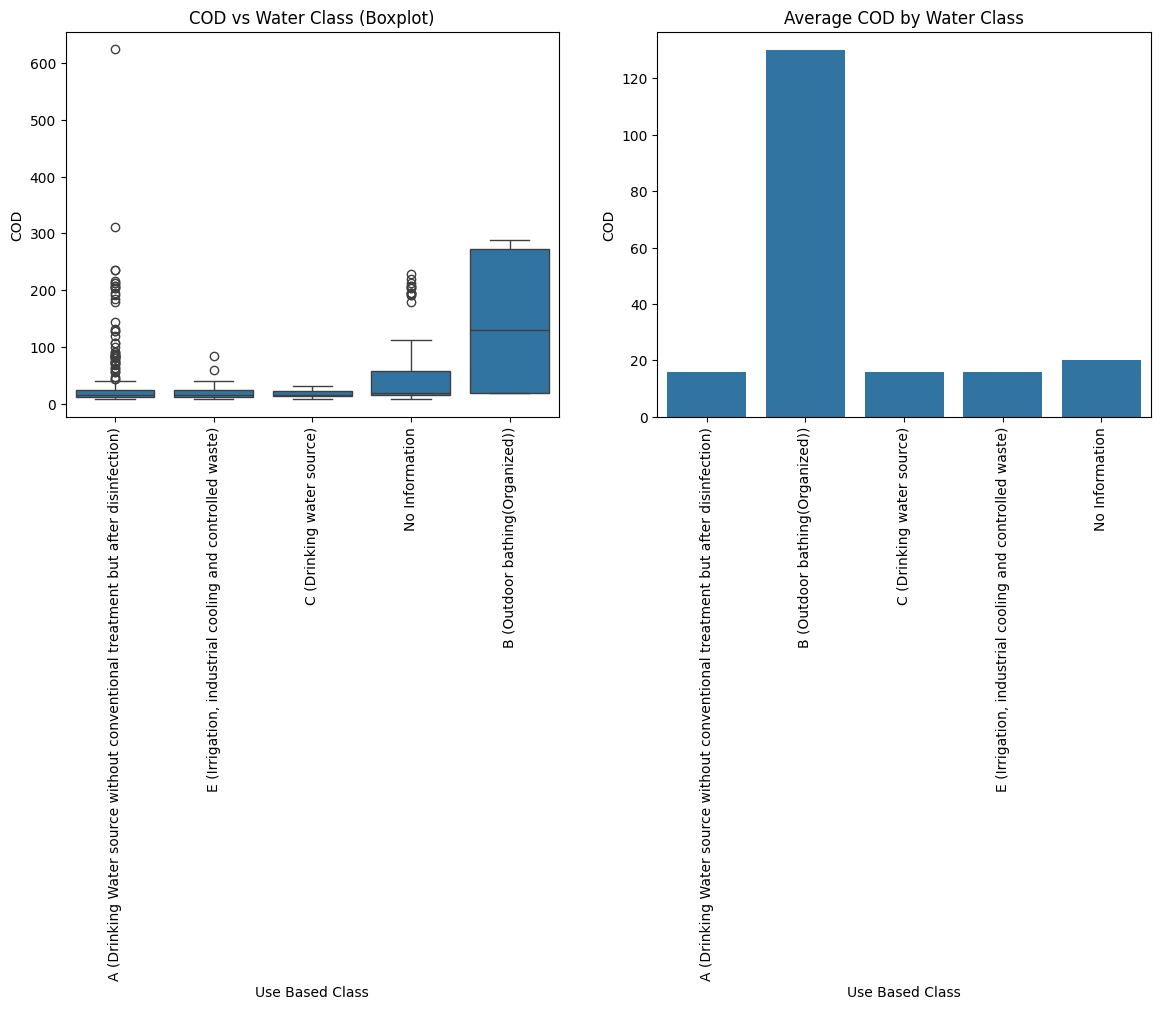

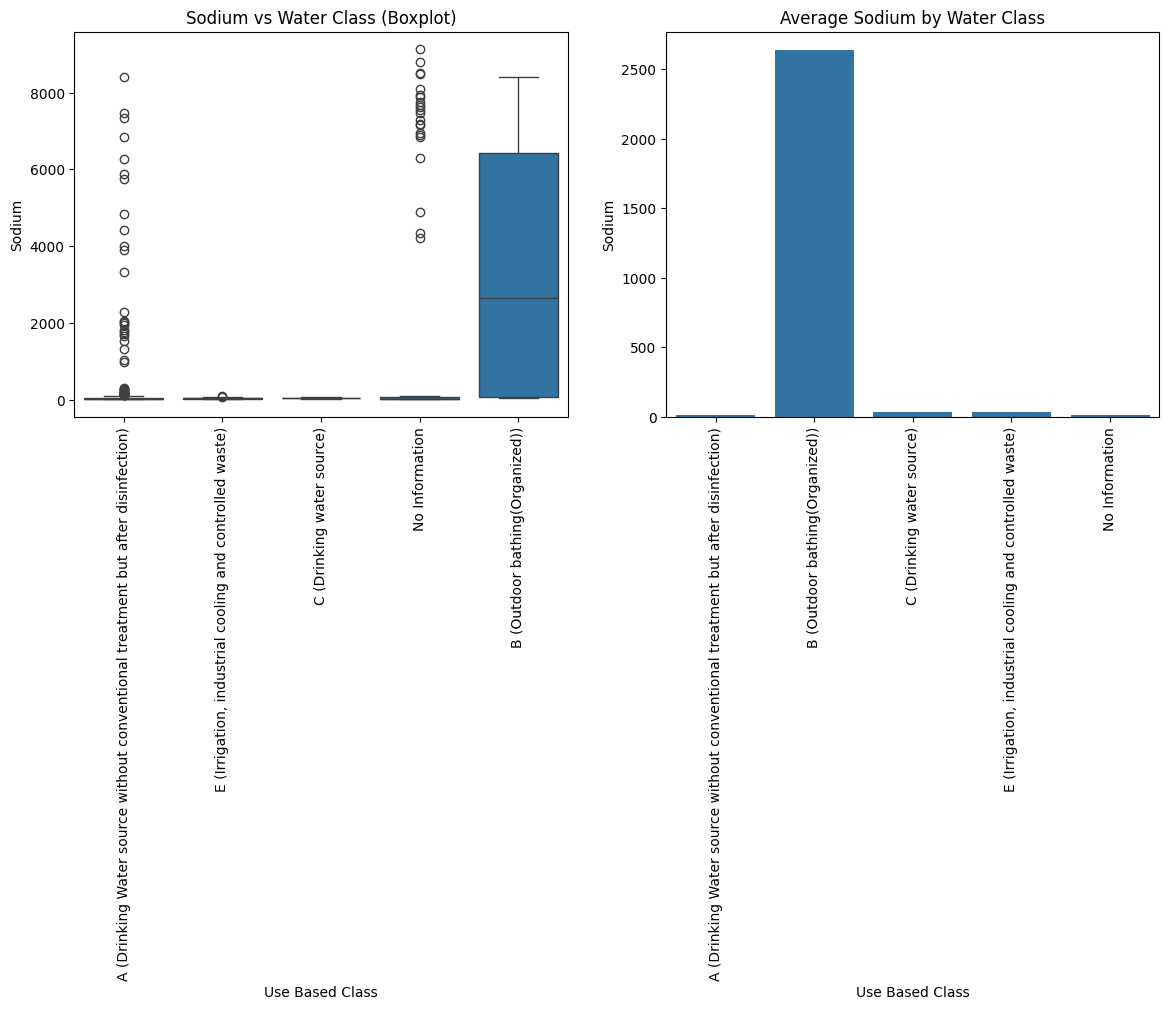

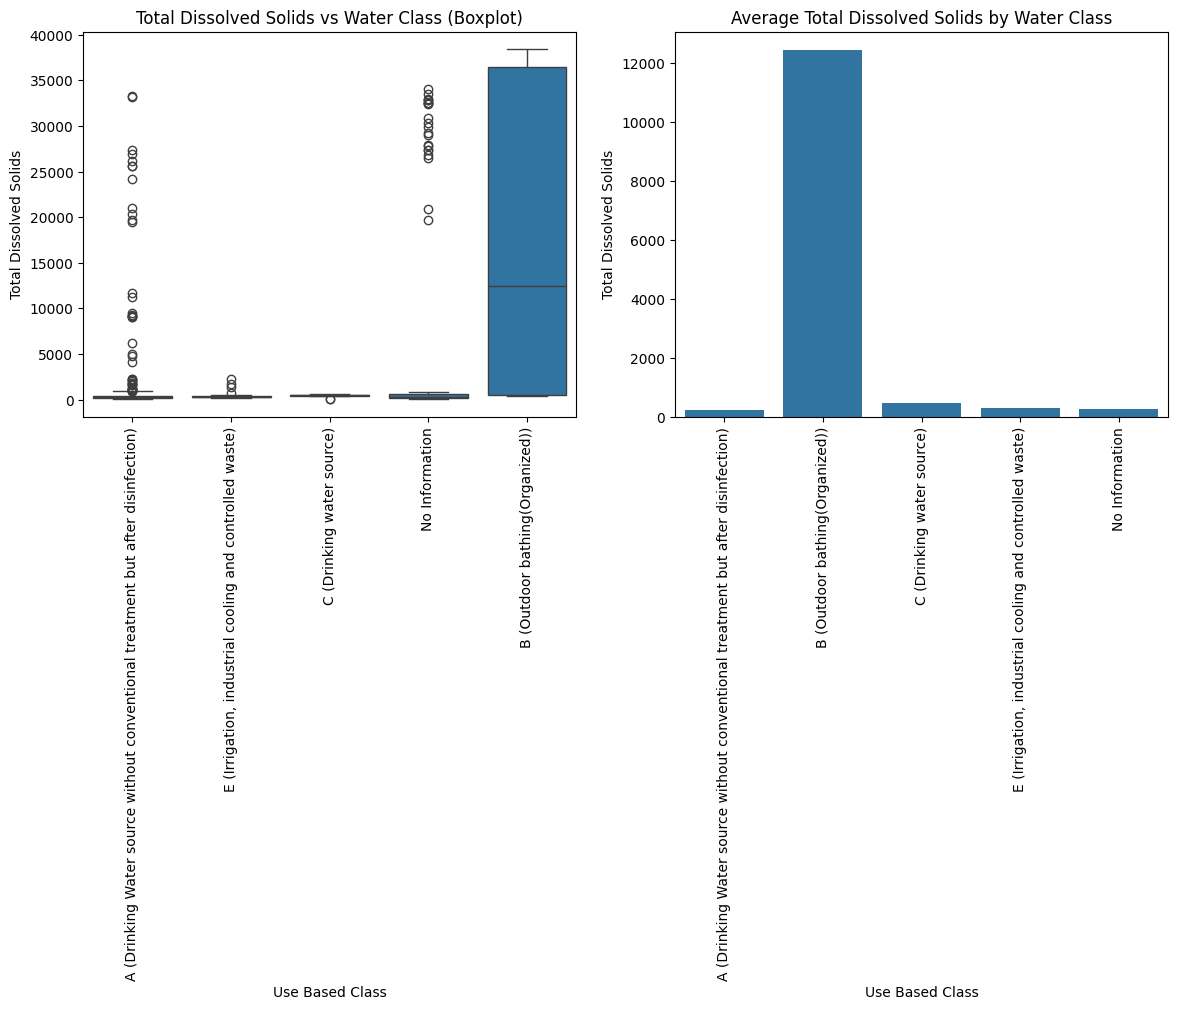

In [34]:
columns=[  'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform', 'Turbidity',
          'Total Alkalinity', 'COD', 'Sodium', 'Total Dissolved Solids']
for column in columns:
  plot_bivariate(column)



##### Insight(s) i found from the chart is below


Dissolved Oxygen (DO)

Usually, Class A should have higher DO compared to lower-quality classes.
In this graph, Class C shows slightly higher DO than Class A, and there is strong overlap between A, B, and C. Class E and “No Information” show lower DO.

DO provides moderate separation but does not clearly separate all classes.


Conductivity

Usually, higher conductivity indicates more dissolved salts and poorer water quality. Class A is expected to have lower conductivity.
In this graph, Class B has extremely high conductivity, while Class A and Class C remain low.

Conductivity clearly separates Class B from other classes and provides strong separation.


BOD

Usually, Class A should have low BOD, and poorer classes should have higher BOD.
In this graph, Class A and Class C have lower BOD, while Class B has the highest BOD.

BOD shows visible variation across classes and provides moderate separation.



Nitrate N

Higher nitrate generally indicates agricultural pollution and lower water quality. Class A is expected to have lower nitrate levels.
In this graph, Class E and “No Information” show slightly higher nitrate values, while Class B is lower.

Separation is weak to moderate due to overlapping values.



Fecal Coliform

Class A should have low fecal coliform levels.
In this graph, Class E shows higher fecal coliform levels, while Class C remains lower. Class A is not always the lowest.

It provides moderate separation but has high variability.

Total Coliform

Class A is expected to have low total coliform levels.
In this graph, “No Information” shows the highest values. Class A is lower but not clearly separated from all others.

This feature provides moderate separation with heavy skewness.



Turbidity

Lower turbidity is expected in Class A.
In this graph, Class E shows higher turbidity, while Class A and C remain lower.

Turbidity provides moderate separation.



Total Alkalinity

Higher alkalinity may indicate poorer quality. Class A is expected to have moderate levels.
In this graph, Class E has the highest alkalinity, while Class A and C remain lower.

Provides moderate separation.


COD

Class A should have low COD, and polluted classes should have high COD.
In this graph, Class B shows extremely high COD, while Class A and C remain much lower.

COD provides strong separation, especially for highly polluted class.


**Overall:-**


COD,
Total Alkalinity,
Turbidity,
BOD,
Conductivity


1. Conductivity
   Very strong separation.
   Class B is extremely high.
   Class A and C are low.
   Matches theory: higher dissolved salts mean poorer water quality.

2. COD
   Very strong separation.
   Class B is extremely high.
   Class A is low.
   Matches theory: higher chemical oxygen demand means more pollution.

3. BOD
   Moderate to strong separation.
   Class A low.
   Class B higher.
   Matches expected pollution trend.

4. Total Alkalinity
   Class E higher.
   Class A moderate to lower.
   Good pattern and somewhat consistent with pollution load.

5. Turbidity
   Class E higher.
   Class A lower.
   Some overlap but pattern exists.

Important observation:

Conductivity and COD clearly separate Class B strongly.

Total Alkalinity and Turbidity help differentiate Class E.

BOD helps differentiate polluted vs clean classes.




#### Stripplot for base classes vs imp numeric variables

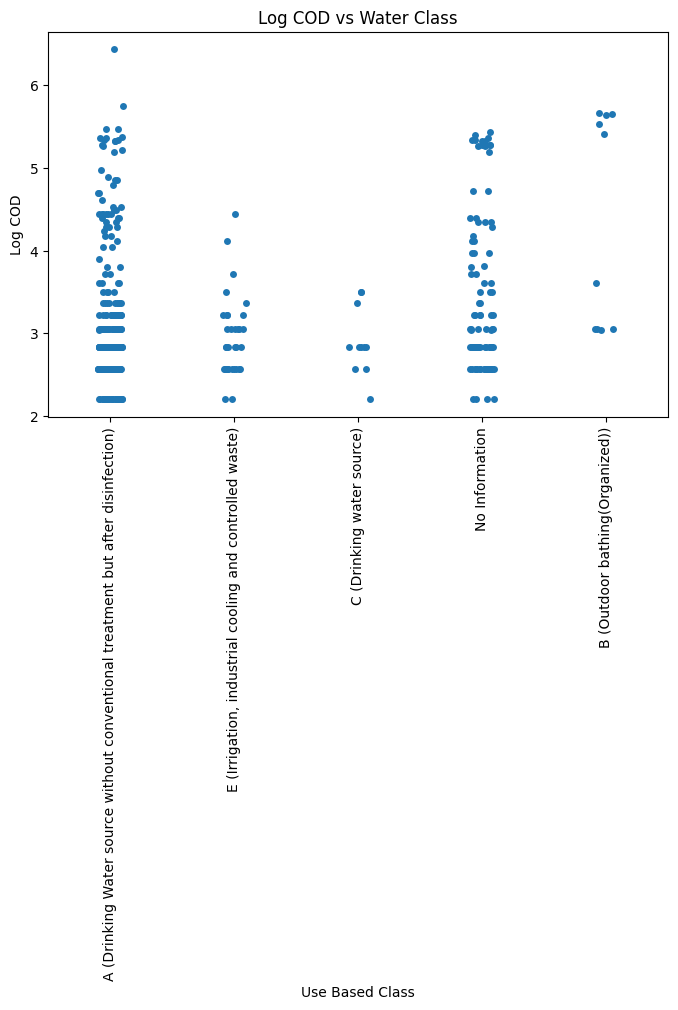

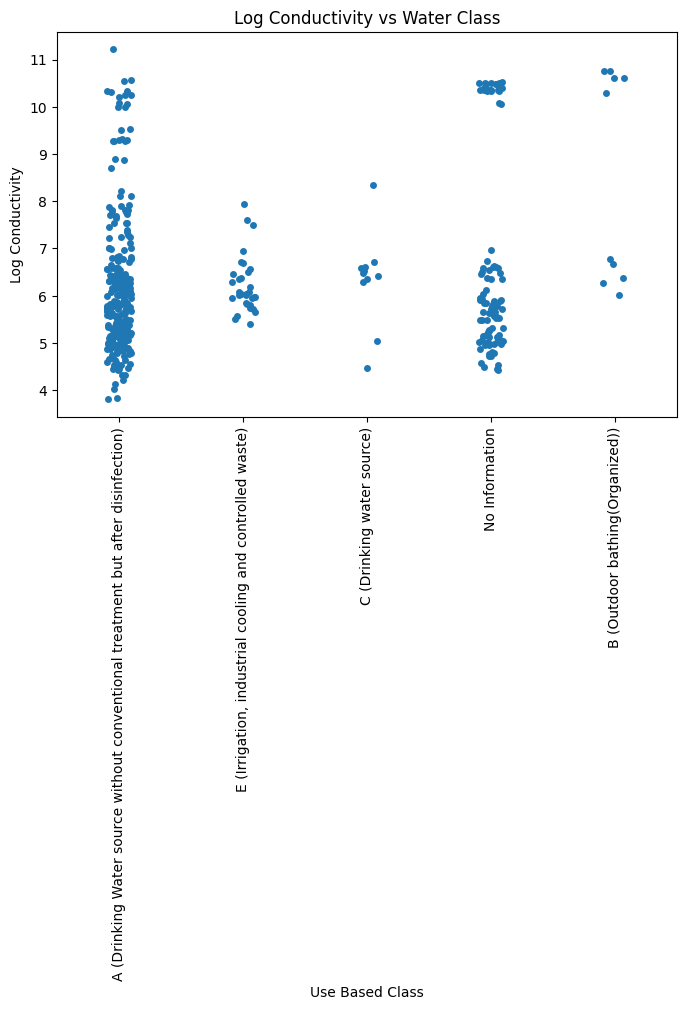

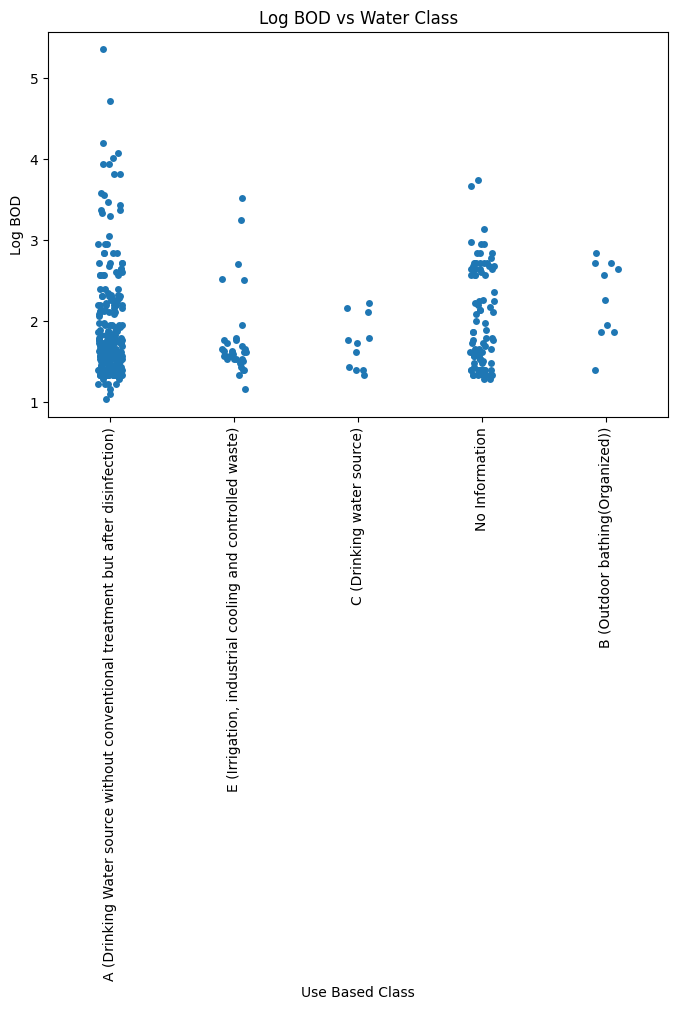

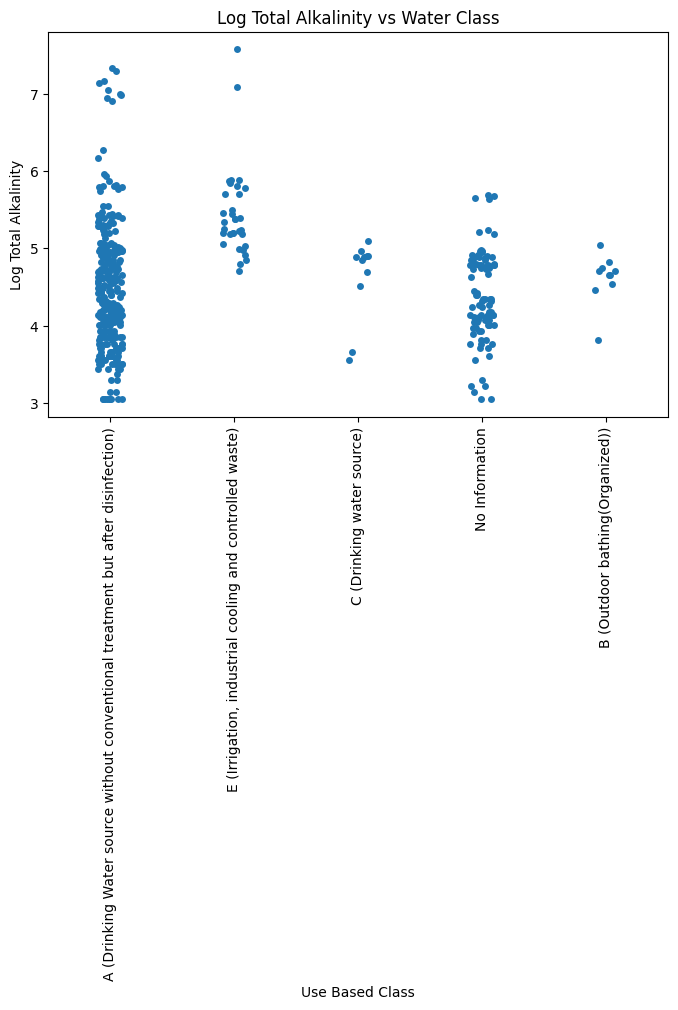

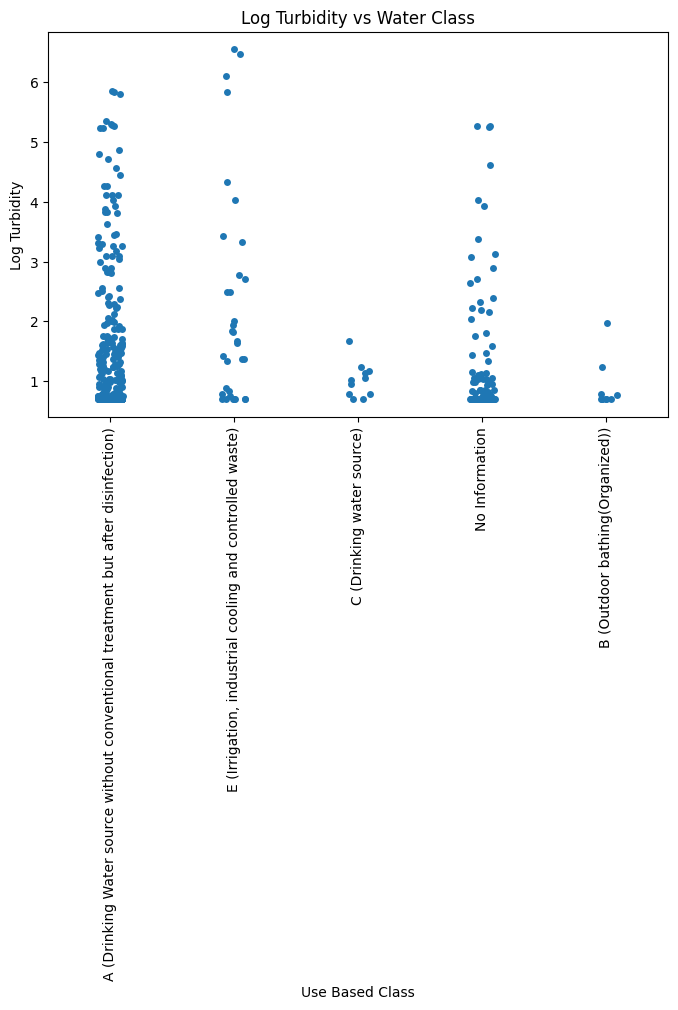

In [35]:

important_features = [
    'COD',
    'Conductivity',
    'BOD',
    'Total Alkalinity',
    'Turbidity'
]

for feature in important_features:

    plt.figure(figsize=(8,5))

    sns.stripplot(
        x='Use Based Class',
        y=np.log1p(new_df[feature]),   # log transformation
        data=new_df,
        jitter=True
    )

    plt.xticks(rotation=90)
    plt.title(f'Log {feature} vs Water Class')
    plt.ylabel(f'Log {feature}')
    plt.tight_layout()
    plt.show()



1. COD (Log)

Class B has many higher log COD values compared to C and E.
Class C is tightly clustered at lower values.
Class A still overlaps a lot.

Conclusion:
Some separation exists, mainly B vs C.
But A overlaps heavily.
So moderate separation, not strong.


2. Conductivity (Log)

Class B clearly has very high log conductivity values.
Class C is much lower and tightly grouped.
Class A has wide spread and overlaps.

Conclusion:
Strong separation for Class B.
Weak separation among A, E, and No Information.


3. BOD (Log)

Class C has lowest cluster.
Class B and No Information slightly higher.
Class A overlaps heavily with others.

Conclusion:
Weak to moderate separation.
Not very strong visually.


4. Total Alkalinity (Log)

Class E appears slightly higher than A and C.
But heavy overlap exists.

Conclusion:
Mild separation for Class E.
Overall moderate at best.



5. Turbidity (Log)

Class C is clearly lowest cluster.
Class E and A show higher spread.
But again, overlap exists.

Conclusion:
Weak to moderate separation.



in this  Water class is determined by multiple parameters together.
No single variable perfectly separates classes.






### **Multivariate Analysis**

####  Correlation Heatmap

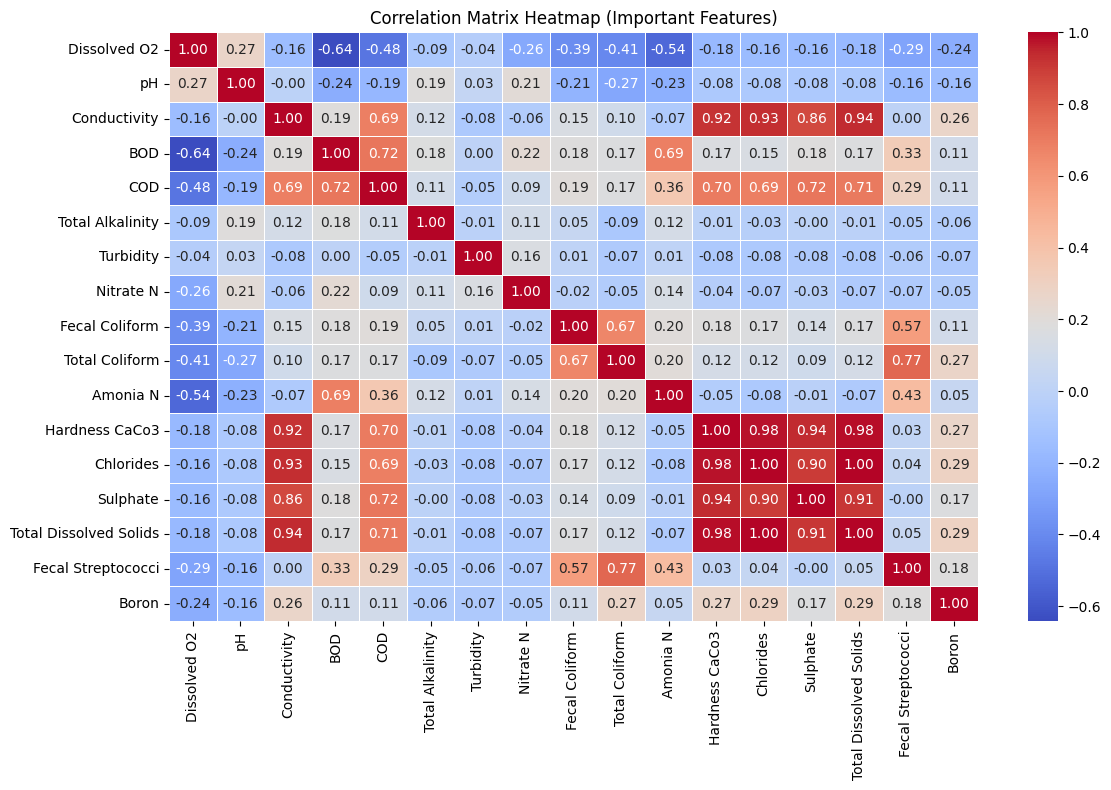

In [36]:
important_numeric = [
    'Dissolved O2',
    'pH',
    'Conductivity',
    'BOD',
    'COD',
    'Total Alkalinity',
    'Turbidity',
    'Nitrate N',
    'Fecal Coliform',
    'Total Coliform',
    'Amonia N',
    'Hardness CaCo3',
    'Chlorides',
    'Sulphate',
    'Total Dissolved Solids','Fecal Streptococci','Boron'
]

corr_data = new_df[important_numeric]

correlation_matrix = corr_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Matrix Heatmap (Important Features)')
plt.tight_layout()
plt.show()



Correlation Analysis Insights

A correlation heatmap was generated using key water quality parameters to understand relationships and detect multicollinearity.

Very strong positive correlations were observed among Conductivity, Total Dissolved Solids, Chlorides, and Hardness CaCO3 (above 0.90). This indicates that these variables represent similar dissolved mineral characteristics and are highly redundant. Only one or two of these features should be retained during modeling to avoid multicollinearity.

BOD and COD show strong positive correlation (0.72), confirming that biological and chemical pollution indicators move together. COD also strongly correlates with Conductivity and Total Dissolved Solids, suggesting pollution increases dissolved mineral content.

Dissolved Oxygen shows strong negative correlation with BOD (-0.64), Ammonia (-0.54), and COD (-0.48). This confirms that as pollution increases, oxygen levels decrease, which is scientifically consistent.

pH, Turbidity, and Nitrate show relatively weak correlations with most variables, indicating limited linear relationships.



####  Pair Plot

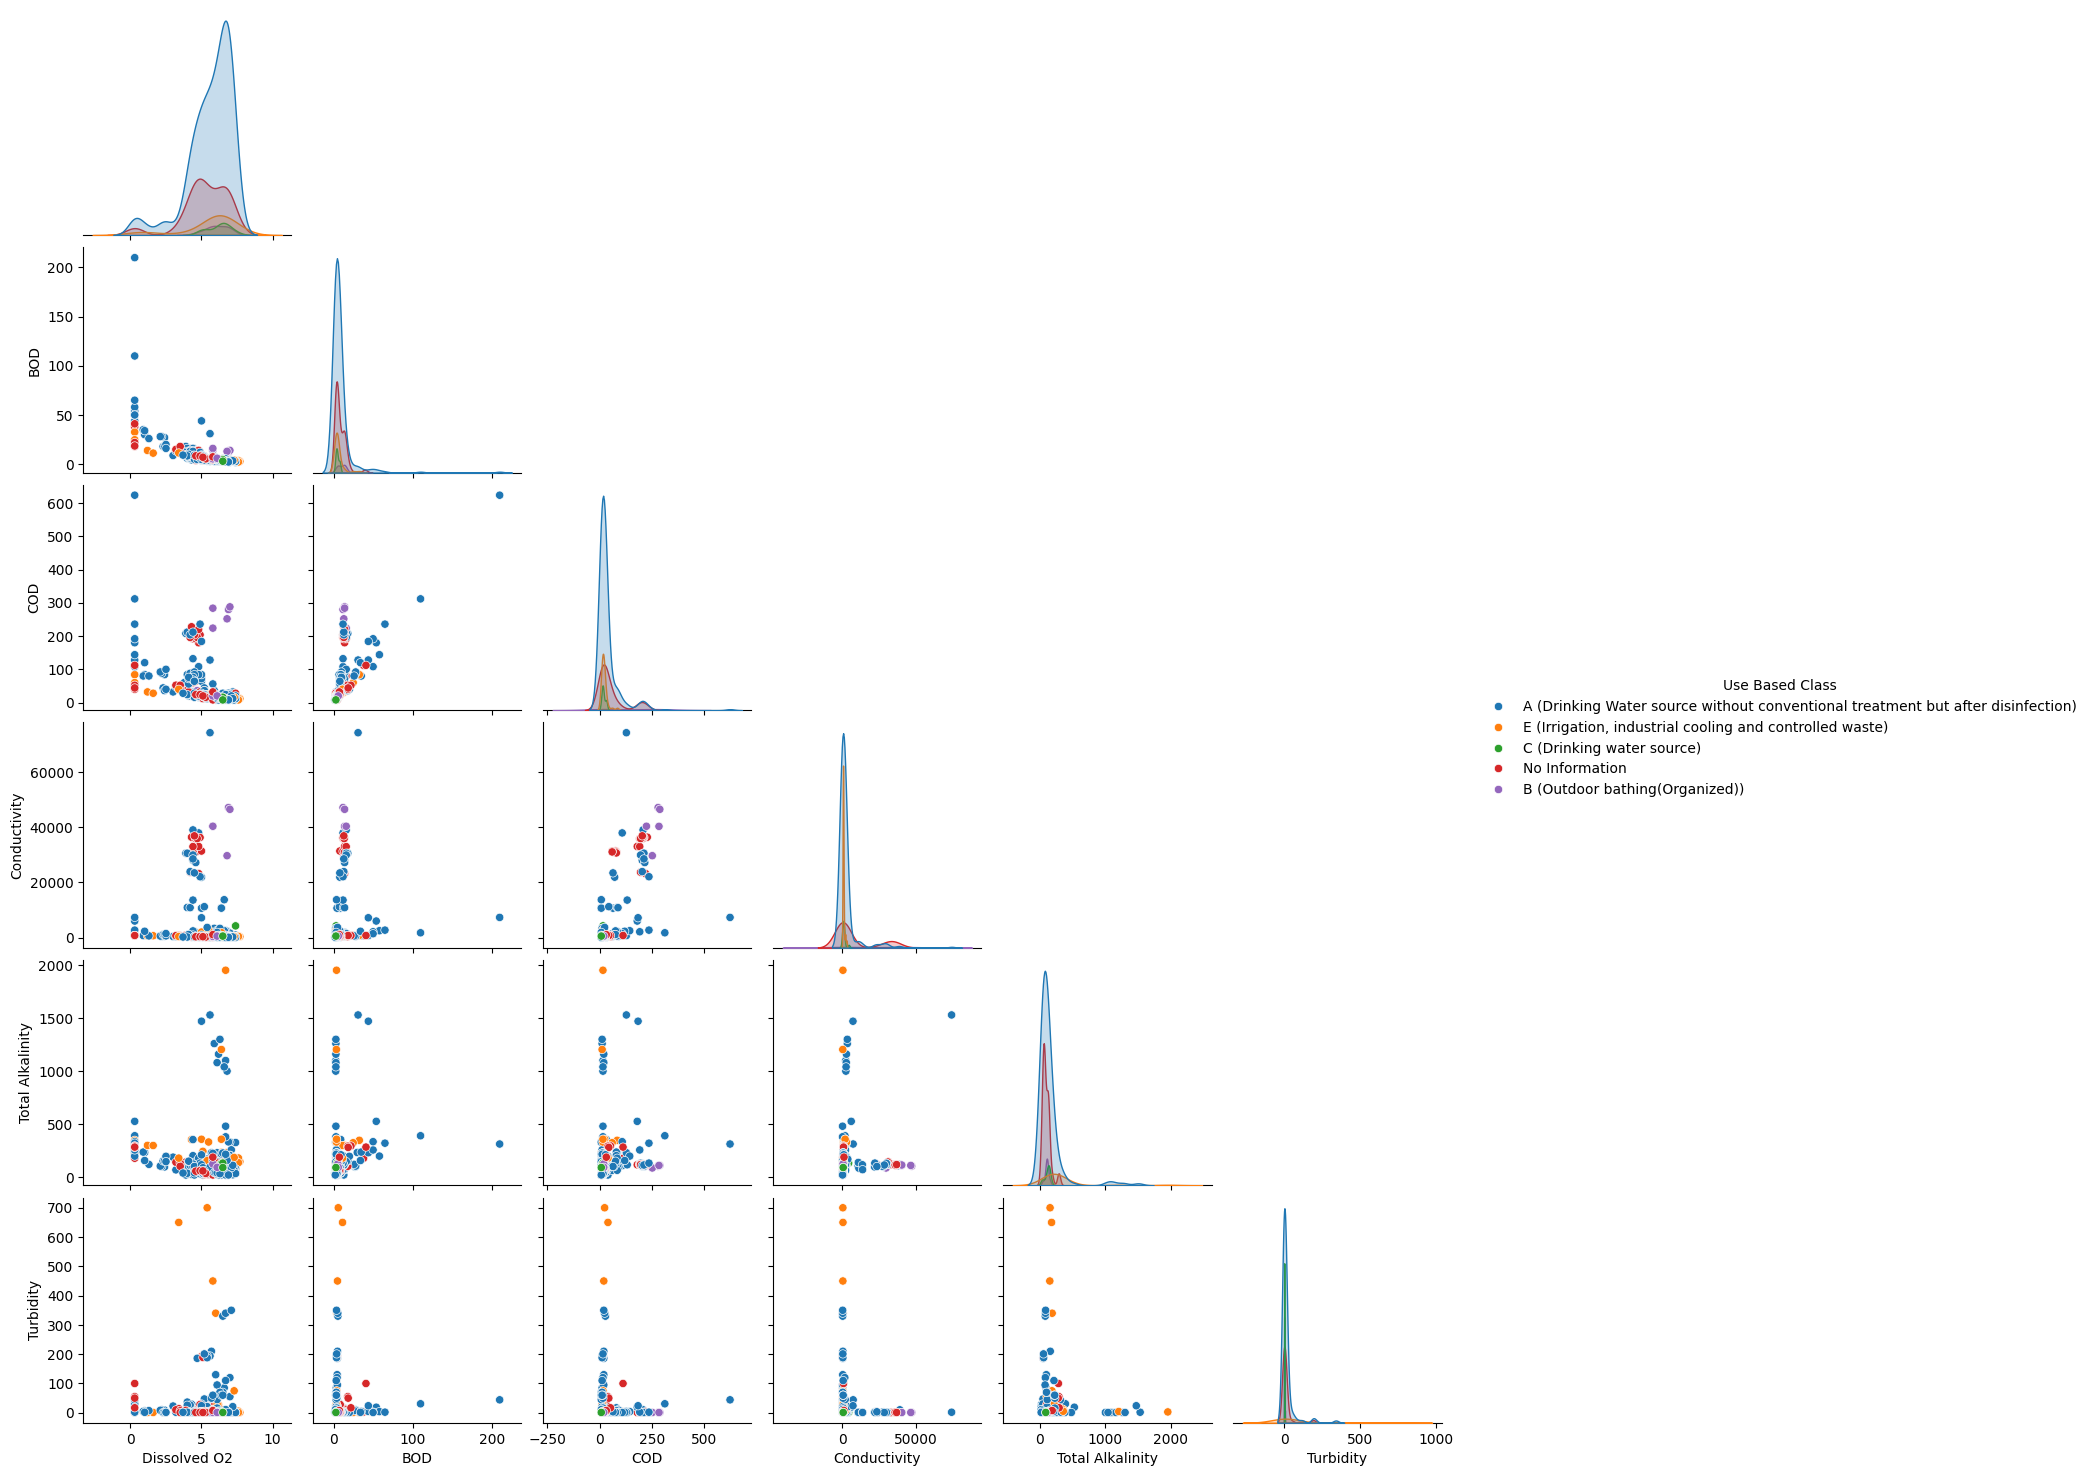

In [37]:

pairplot_features = [
    'Dissolved O2',
    'BOD',
    'COD',
    'Conductivity',
    'Total Alkalinity',
    'Turbidity'
]

sns.pairplot(
    new_df[pairplot_features + ['Use Based Class']],
    hue='Use Based Class',
    diag_kind='kde',
    corner=True
)

plt.show()


Pairplot Analysis Insights

The pairplot shows clear negative correlation between Dissolved Oxygen and BOD, confirming that higher pollution reduces oxygen levels. Class C mostly appears in the high DO and low BOD region.

BOD and COD show strong positive correlation, indicating that biological and chemical pollution increase together.

Conductivity and COD show moderate separation, especially for Class B, which tends to cluster in higher pollution regions.

However, significant overlap exists among classes across most feature combinations. No single feature or pair clearly separates all classes.

This indicates that water classification depends on multiple parameters together, and machine learning is required to capture complex relationships.



## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

The average BOD of Class A is greater than or equal to the overall mean.

H₀: μ_ClassA ≥ μ_Overall

Alternative Hypothesis (H₁):

The average BOD of Class A is lower than the overall mean.

H₁: μ_ClassA < μ_Overall

Test Type: One-Tailed One-Sample t-Test (Left-Tailed)

In [38]:
new_df['Use Based Class'].unique()

array(['A (Drinking Water source without conventional treatment but after disinfection)',
       'E (Irrigation, industrial cooling and controlled waste)',
       'C (Drinking water source)', 'No Information',
       'B (Outdoor bathing(Organized))', nan], dtype=object)

#### 2. Perform an appropriate statistical test.

In [39]:
overall_mean_of_bod = new_df['BOD'].mean()
class_a_bod_of_dataset = new_df[new_df['Use Based Class'] == 'A (Drinking Water source without conventional treatment but after disinfection)']['BOD'].mean()


In [40]:
overall_mean_of_bod

np.float64(7.933715596330276)

In [41]:
class_a_bod_of_dataset

np.float64(8.123958333333333)

In [42]:
from scipy.stats import ttest_1samp
import numpy as np

# Drop missing values
overall_mean = new_df['BOD'].dropna().mean()
class_a_bod = new_df[new_df['Use Based Class'] == 'A (Drinking Water source without conventional treatment but after disinfection)']['BOD'].dropna()

# Perform two-tailed test first
t_statistic, p_value_two_tailed = ttest_1samp(class_a_bod, overall_mean)

# Convert to one-tailed (left-tailed)
if t_statistic < 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

print("T-Statistic =", round(t_statistic, 3))
print("One-Tailed P-Value =", round(p_value_one_tailed, 5))

alpha = 0.05

if p_value_one_tailed < alpha:
    print("Reject the null hypothesis: Mean BOD of Class A is significantly lower than overall mean.")
else:
    print("Fail to reject the null hypothesis: No evidence that Class A BOD is lower.")

T-Statistic = 0.201
One-Tailed P-Value = 0.57947
Fail to reject the null hypothesis: No evidence that Class A BOD is lower.


##### Which statistical test have you done to obtain P-Value?

I have performed a one-sample t-test to obtain the p-value.

##### Why did you choose the specific statistical test?

I chose the t-test because the population standard deviation (σ) is unknown.
Even though the BOD mean is not perfectly normally distributed, the t-test is still robust with enough sample sizes due to the Central Limit Theorem.
.
That's why the one-sample t-test was suitable here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [123]:
df6=new_df.copy()

In [104]:
# Inspecting null/missing value count and percentage
null_df = pd.DataFrame({
    'percentage_null_values': round(df6.isna().sum() * 100 / len(df6), 2),'missing_value_count': df6.isna().sum()
}).sort_values(by='percentage_null_values', ascending=False)
null_df

,percentage_null_values,missing_value_count
Visibility Effluent Discharge,40.77,181
Major Polluting Sources,31.53,140
Fecal Streptococci,20.72,92
Boron,13.29,59
Temperature,11.26,50
River Basin,10.81,48
Name Of Water Body,9.91,44
Flouride,5.86,26
Phenophelene Alkanity,3.15,14
Phosphate,3.15,14


In [124]:
# Columns to drop
columns_to_drop = [
    " Visibility Effluent Discharge",
    "Major Polluting Sources",
    "River Basin",
    "Name Of Water Body",
    "latitude",
    "longitude",
    "Human Activities",
    "Weather",
    "District",
    "Frequency",
    "Fecal Streptococci","Floating Matter"
]

# Drop columns
df6.drop(columns=columns_to_drop, inplace=True)

# Check remaining columns
df6.shape

(444, 39)

Feature Removal Reason:

Dropped columns with >30% missing values.

Removed location and text-based columns not useful for prediction.

Removed Fecal Streptococci due to high correlation (0.77) with Total Coliform and 20% missing values.

Reduced dimensionality and also dataset is small so dont want to add redundency

In [125]:
# Median imputation for numeric columns
df6.fillna(df6.median(numeric_only=True), inplace=True)

# categorical column mode imputation
df6['Color'].fillna(df6['Color'].mode()[0], inplace=True)

In [126]:
# Remove rows where target is NaN
df6 = df6[df6["Use Based Class"].notna()]

# Remove rows where target is "No Information"
df6 = df6[df6["Use Based Class"] != "No Information"]

# Reset index
df6.reset_index(drop=True, inplace=True)

df6.shape

(342, 39)

Rows with missing target values were removed because supervised learning requires valid class labels.

"No Information" entries were removed as they do not represent valid water quality classes.

Keeping them would introduce noise and reduce model reliability.

Final model focuses only on valid classes: A, B, C, and E.

For handling missing value i used median and mode imputation techniques

In [127]:
df6.drop(columns=['STN Code','Sampling Date',], inplace=True)


### 2. Handling Outliers

In [49]:
df6.columns

Index(['Month', 'Sampling Time', 'Stn Name', 'Type Water Body', 'State Name',
       'Mon Agency', 'Use Based Class', 'Approx Depth', 'Color', 'Flow',
       'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
       'Fecal Coliform', 'Total Coliform', 'Turbidity',
       'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD',
       'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3',
       'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids',
       'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron',
       'Potassium', 'Flouride'],
      dtype='object')

In [50]:
df6.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow,342.0,0.382164,1.139199,0.0,0.0000,0.000,0.0000,8.00
Temperature,342.0,25.714912,3.268284,16.0,25.0000,27.000,28.0000,32.00
Dissolved O2,342.0,5.645906,1.569531,0.3,5.0000,6.000,6.8000,7.70
pH,342.0,7.906784,0.434868,6.9,7.5000,7.900,8.2000,9.70
Conductivity,342.0,2649.447368,8249.996685,44.0,188.0000,384.000,720.0000,74240.00
BOD,342.0,7.875439,14.933942,1.8,3.2000,4.000,7.2000,210.00
Nitrate N,342.0,1.406257,1.593857,0.3,0.5525,0.850,1.9225,21.00
Fecal Coliform,342.0,72.179240,146.132006,1.8,8.2000,26.000,94.0000,1600.00
Total Coliform,342.0,374.040351,402.790908,1.8,94.0000,280.000,540.0000,1600.00
Turbidity,342.0,19.969211,72.460634,1.0,1.0000,1.475,5.1050,700.00


* By seeing descriptive statistic of numerical variable we can see that numeric columns is highly skewed

In [128]:


skewed_cols = [
    "Conductivity", "BOD", "COD", "Turbidity",
    "Chlorides", "Total Dissolved Solids",
    "Total Fixed Solids", "Hardness CaCo3",
    "Calcium CaCo3", "Magnesium CaCo3",
    "Sulphate", "Sodium", "Potassium",
    "Fecal Coliform", "Total Coliform"
]

for col in skewed_cols:
    df6[col] = np.log1p(df6[col])

Due to extreme right-skewed distributions in chemical parameters, log transformation was applied instead of removing outliers. This preserves data size while reducing the influence of extreme values.

###   Feature Engineering(Feature creation)

Combine major pollution indicators:

In [129]:
df6['Pollution_Index'] = (
    df6['COD'] +
    df6['BOD']
)

Pollution Ratio Feature

BOD / DO

High BOD + Low DO = polluted water

In [130]:
df6["BOD_DO_Ratio"] = df6["BOD"] / (df6["Dissolved O2"] + 1e-5)

In [54]:
df6.columns

Index(['Month', 'Sampling Time', 'Stn Name', 'Type Water Body', 'State Name',
       'Mon Agency', 'Use Based Class', 'Approx Depth', 'Color', 'Flow',
       'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
       'Fecal Coliform', 'Total Coliform', 'Turbidity',
       'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD',
       'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3',
       'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids',
       'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron',
       'Potassium', 'Flouride', 'Pollution_Index', 'BOD_DO_Ratio'],
      dtype='object')

### Converting Target variable into Binary class

In [131]:
# Check original class distribution
print("Original Class Distribution:\n")
print(df6["Use Based Class"].value_counts())

Original Class Distribution:

Use Based Class
A (Drinking Water source without conventional treatment but after disinfection)    288
E (Irrigation, industrial cooling and controlled waste)                             33
C (Drinking water source)                                                           11
B (Outdoor bathing(Organized))                                                      10
Name: count, dtype: int64


Due to severe class imbalance and the limited size of the dataset, the original multiclass classification problem was reformulated into a binary classification task to ensure more stable and reliable model performance.

In [132]:
# Convert to binary classes
df6["Binary_Class"] = df6["Use Based Class"].replace({
    "A (Drinking Water source without conventional treatment but after disinfection)": "High Quality Water",
    "B (Outdoor bathing(Organized))": "Lower Quality Water",
    "C (Drinking water source)": "Lower Quality Water",
    "E (Irrigation, industrial cooling and controlled waste)": "Lower Quality Water"
})

In [139]:
# Check after  class distribution
print("Original Class Distribution:\n")
print(df6["Binary_Class"].value_counts())

Original Class Distribution:

Binary_Class
0    288
1     54
Name: count, dtype: int64


### 3. Categorical Encoding

In [133]:
# drop unnecessary column
df6.drop(columns=['Month','Sampling Time','Stn Name','State Name','Mon Agency','Approx Depth'
], inplace=True)

In [134]:
df6.drop(columns=["Color"], inplace=True)

 Type Water Body columns endcoding using one hot encoding

In [135]:
df6["Type Water Body"] = df6["Type Water Body"].str.strip().str.lower()

df6 = pd.get_dummies(df6, columns=["Type Water Body"], drop_first=True)

Target Variable endcoding with label encoding

In [136]:
df6["Binary_Class"] = df6["Binary_Class"].map({
    "High Quality Water": 0,
    "Lower Quality Water": 1
})

###  Feature Manipulation & Selection

#### Feature Selection and manipulation

In [137]:
df6.columns

Index(['Use Based Class', 'Flow', 'Temperature', 'Dissolved O2', 'pH',
       'Conductivity', 'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform',
       'Turbidity', 'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides',
       'COD', 'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3',
       'Calcium CaCo3', 'Magnesium CaCo3', 'Sulphate', 'Sodium',
       'Total Dissolved Solids', 'Total Fixed Solids',
       'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium', 'Flouride',
       'Pollution_Index', 'BOD_DO_Ratio', 'Binary_Class',
       'Type Water Body_dam', 'Type Water Body_lake', 'Type Water Body_nala',
       'Type Water Body_river', 'Type Water Body_sea'],
      dtype='object')

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# 1️ Separate target and features
y = df6["Binary_Class"]
X = df6.drop(["Use Based Class", "Binary_Class"], axis=1)

# 2️ Train-Test Split FIRST (very important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3️ Remove constant features (fit ONLY on training data)
var_selector = VarianceThreshold(threshold=0)
X_train_var = X_train.loc[:, var_selector.fit(X_train).get_support()]
X_test_var = X_test.loc[:, var_selector.get_support()]

# 4️ Remove highly correlated features (based ONLY on training data)
corr_matrix = X_train_var.corr()
high_corr_features = set()
threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_features.add(corr_matrix.columns[i])

X_train_uncorr = X_train_var.drop(columns=high_corr_features)
X_test_uncorr = X_test_var.drop(columns=high_corr_features)

# 5️ Random Forest Feature Importance (train only)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_uncorr, y_train)

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_uncorr.columns
).sort_values(ascending=False)

# Results
print("Top 17 Features by RandomForest:\n", importances.head(17))
print("\nRemoved Highly Correlated Features:\n", list(high_corr_features))

Top 17 Features by RandomForest:
 Total Suspended Solids    0.095602
Total Alkalinity          0.093008
Conductivity              0.091187
Temperature               0.077222
Dissolved O2              0.064432
Turbidity                 0.063990
BOD_DO_Ratio              0.060308
Sulphate                  0.059944
Nitrate N                 0.059573
Phenophelene Alkanity     0.058200
pH                        0.051569
Fecal Coliform            0.045625
Total Coliform            0.042239
Flouride                  0.030875
Flow                      0.028503
Total Kjeldahl N          0.021162
Phosphate                 0.019624
dtype: float64

Removed Highly Correlated Features:
 ['Hardness CaCo3', 'Potassium', 'Magnesium CaCo3', 'BOD', 'Sodium', 'Pollution_Index', 'Chlorides', 'Type Water Body_lake', 'Calcium CaCo3', 'Total Dissolved Solids', 'Total Fixed Solids', 'Amonia N', 'COD']


In [64]:
# Select top 17 features
top_17_features = importances.head(17).index

# Reduce training and test set
X_train = X_train_uncorr[top_17_features]
X_test= X_test_uncorr[top_17_features]


1. **Stratified Train-Test Split (80–20)**
   The dataset was split into 80 percent training and 20 percent testing sets using stratified sampling to preserve class distribution.

2. **Removal of Constant Features**
   Features with zero variance were removed using VarianceThreshold since they do not provide useful information.

3. **Removal of Highly Correlated Features**
   Features with correlation greater than 0.85 were eliminated based on the training data to reduce redundancy and multicollinearity.

4. **Feature Importance using Random Forest**
   A Random Forest model was trained on the processed training data, and the top 17 most important features were selected based on importance scores.

5. **Avoiding Data Leakage**
   All preprocessing steps were performed only on the training data and then applied to the test set to ensure unbiased evaluation.


## ***7. ML Model Implementation***

### ML Model - 1- LogisticRegression

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a pipeline to avoid data leakage and keep preprocessing organized
pipe_lr = Pipeline([

    # Step 1: Standardize features
    # Logistic Regression is sensitive to feature scale,
    # so we normalize features to mean=0 and std=1
    ("scaler", StandardScaler()),

    # Step 2: Logistic Regression model
    # class_weight="balanced" handles class imbalance automatically
    # max_iter=1000 ensures convergence
    # random_state=42 ensures reproducibility
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Train the pipeline (scaling + model training happens together)
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [66]:
y_pred = pipe_lr.predict(X_test)

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[46 12]
 [ 5  6]]

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        58
           1       0.33      0.55      0.41        11

    accuracy                           0.75        69
   macro avg       0.62      0.67      0.63        69
weighted avg       0.81      0.75      0.78        69



Logistic Regression achieved an overall accuracy of 75% with a macro F1-score of 0.63. While the model showed moderate recall (0.55) for the minority class, precision remained low (0.33), indicating difficulty in correctly identifying non-Class A samples.

### Comprehensive Evaluation Function for Classification Models

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def evaluate_model(model, X_test, y_test, plot_roc=True):

    # Define binary class labels (0 = Class A, 1 = Non-A)
    correct_classes = [0, 1]

    # Generate predictions
    y_pred = model.predict(X_test)

    # Handle 2D outputs
    if len(y_pred.shape) > 1:
        y_pred = y_pred.ravel()

    y_pred = pd.Series(y_pred).astype(int)
    y_test = pd.Series(y_test).astype(int)

    # Classification Report
    print("<=== Classification Report ===>")
    print(classification_report(y_test, y_pred, labels=correct_classes))

    # Confusion Matrix
    print("\n=== Confusion Matrix ===>")
    cm = confusion_matrix(y_test, y_pred, labels=correct_classes)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=correct_classes,
                yticklabels=correct_classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    if hasattr(model, "predict_proba") and plot_roc:
        y_score = model.predict_proba(X_test)

        auc_score = roc_auc_score(y_test, y_score[:, 1])
        print(f"\nBinary ROC-AUC Score: {auc_score:.4f}")

        plt.figure(figsize=(8, 6))
        fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve - Binary Classification")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

### ML Model - 2-Random Forest

<=== Classification Report ===>
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        58
           1       1.00      0.64      0.78        11

    accuracy                           0.94        69
   macro avg       0.97      0.82      0.87        69
weighted avg       0.95      0.94      0.94        69


=== Confusion Matrix ===>


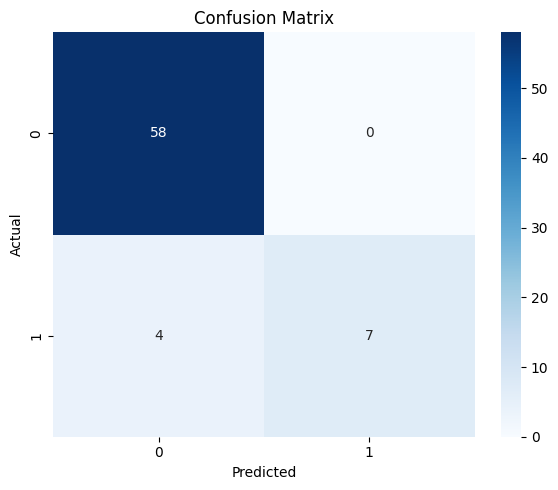


Binary ROC-AUC Score: 0.9404


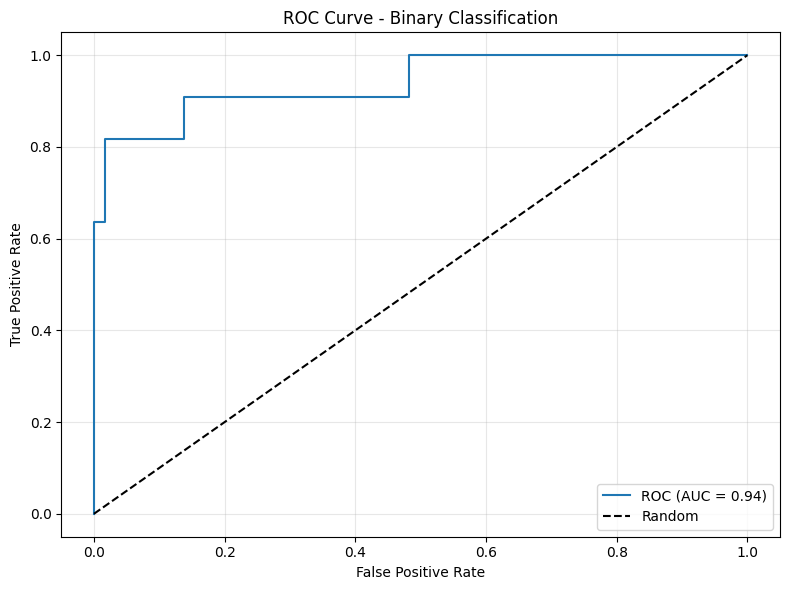

In [69]:
from sklearn.ensemble import RandomForestClassifier
import traceback

try:
    # Initialize Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=300,          # Number of trees (more trees → more stable predictions)
        max_depth=None,            # Allow trees to grow fully (can capture complex patterns)
        min_samples_split=5,       # Minimum samples required to split a node (reduces overfitting)
        min_samples_leaf=3,        # Minimum samples required at a leaf node (adds regularization)
        random_state=42,           # Ensures reproducibility
        n_jobs=-1,                 # Uses all CPU cores for faster training
        class_weight={0: 1, 1: 5}  # Assign higher weight to minority class (handles imbalance)
    )

    # Train the model on training data
    rf_model.fit(X_train, y_train)

    # Generate predictions on test data
    rf_pred = rf_model.predict(X_test)

except Exception as e:
    print("Error during Random Forest training or evaluation:")
    traceback.print_exc()

# Evaluate the trained model using custom evaluation function
evaluate_model(rf_model, X_test, y_test)

Random Forest achieved an overall accuracy of 94% with a macro F1-score of 0.87. While the model showed perfect precision (1.00) for the minority class, recall remained moderate (0.64), indicating that some non-Class A samples were missed.

Some information about evaluation metrics:

 **Precision:**

Out of all predicted positive samples, how many were actually correct.
→ Measures prediction **quality**.

 **Recall:**

Out of all actual positive samples, how many did the model correctly identify.
→ Measures prediction **coverage**.

**F1-Score:**

Harmonic mean of precision and recall; balances both.
→ Useful when classes are imbalanced.

**Accuracy:**

Total correct predictions out of all predictions.
→ Can be misleading if classes are imbalanced.

**Macro Avg:**

It calculates the average of precision, recall, and F1-score treating all classes equally, no matter how big or small the class is.
→ Good for checking how  model performs on each class without bias.Useful when we want to focus on minority classes too.

**Weighted Avg:**

It calculates the average of precision, recall, and F1-score based on the number of samples in each class.
→ Bigger classes have more influence on the final score.Gives a realistic overall performance, especially when our dataset is imbalanced.

**ROC-AUC Score:**

Measures model’s ability to distinguish between classes using predicted probabilities.
→ Higher AUC = better separability between classes.


####  Cross- Validation & Hyperparameter Tuning

Starting RandomizedSearchCV...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tuning completed.

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}

Best CV Macro F1 Score:
0.7637972902820698

Evaluating on Test Set:
<=== Classification Report ===>
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        58
           1       0.88      0.64      0.74        11

    accuracy                           0.93        69
   macro avg       0.90      0.81      0.85        69
weighted avg       0.92      0.93      0.92        69


=== Confusion Matrix ===>


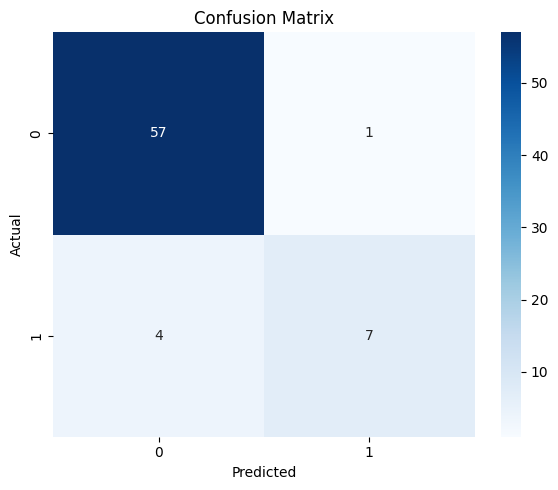


Binary ROC-AUC Score: 0.9357


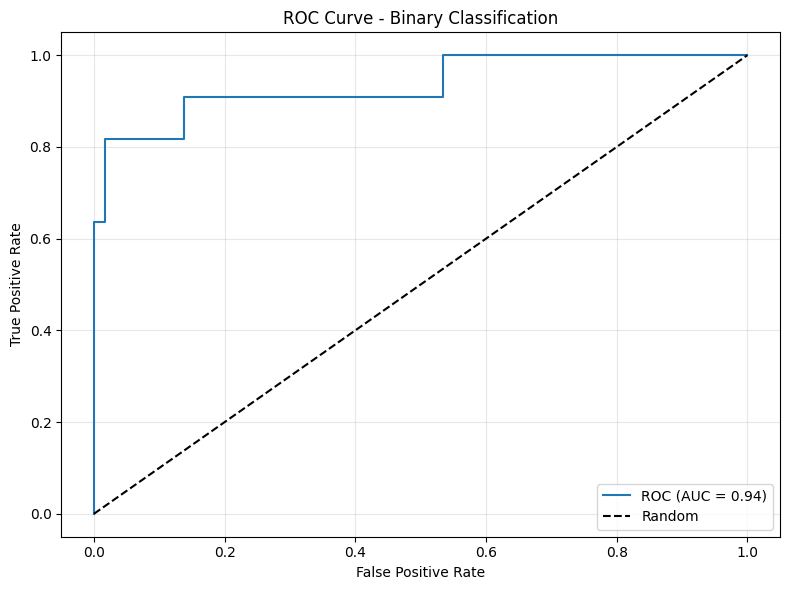

In [70]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import traceback

try:
    # 1️ Define hyperparameter search space
    # Parameters are regularized to reduce overfitting on small dataset
    param_dist = {
        'n_estimators': [150, 250, 350],   # Number of trees (model stability)
        'max_depth': [5, 8, 12],           # Control tree depth (prevent overfitting)
        'max_features': ['sqrt'],          # Feature sampling per split
        'min_samples_split': [5, 10],      # Minimum samples required to split
        'min_samples_leaf': [2, 4, 6]      # Minimum samples per leaf (regularization)
    }

    # 2️ Stratified K-Fold Cross Validation
    # Preserves class distribution in each fold (important for imbalance)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # 3️ Initialize base Random Forest model
    # balanced_subsample handles class imbalance at each tree level
    rf_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample'
    )

    # 4️ Setup RandomizedSearchCV
    # Randomized search is faster than GridSearch for small datasets
    random_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_dist,
        n_iter=15,                  # Try 15 random parameter combinations
        scoring='f1_macro',         # Focus on macro F1 (protect minority class)
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("Starting RandomizedSearchCV...")

    # Train and tune model using cross-validation
    random_search.fit(X_train, y_train)

    print("Tuning completed.")

    # 5️ Retrieve best model
    best_rf = random_search.best_estimator_

    print("\nBest Parameters:")
    print(random_search.best_params_)

    print("\nBest CV Macro F1 Score:")
    print(random_search.best_score_)

    # 6️ Evaluate best model on unseen test data
    print("\nEvaluating on Test Set:")
    evaluate_model(best_rf, X_test, y_test)

except Exception as e:
    print("Error during Random Forest tuning:")
    traceback.print_exc()

### ML Model - 2-XGBoost

In [71]:
from xgboost import XGBClassifier
import traceback

try:
    # Calculate imbalance ratio (majority / minority)
    # Used to give more importance to minority class during training
    ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

    # Initialize XGBoost model with regularization
    xgb_model = XGBClassifier(
        n_estimators=150,          # Number of boosting trees
        max_depth=3,               # Shallow trees to prevent overfitting (important for small dataset)
        learning_rate=0.05,        # Smaller learning rate for smoother learning
        subsample=0.8,             # Use 80% of data per tree (reduces variance)
        colsample_bytree=0.8,      # Use 80% of features per tree (adds randomness)
        min_child_weight=5,        # Prevents overly specific splits (regularization)
        gamma=1,                   # Minimum loss reduction to make a split (controls complexity)
        scale_pos_weight=ratio,    # Handles class imbalance internally
        eval_metric='logloss',     # Binary classification loss function
        random_state=42            # Ensures reproducibility
    )

    # Train the model on training data
    xgb_model.fit(X_train, y_train)

except Exception as e:
    print("Error during XGBoost training:")
    traceback.print_exc()

<=== Classification Report ===>
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.82      0.90        11

    accuracy                           0.97        69
   macro avg       0.98      0.91      0.94        69
weighted avg       0.97      0.97      0.97        69


=== Confusion Matrix ===>


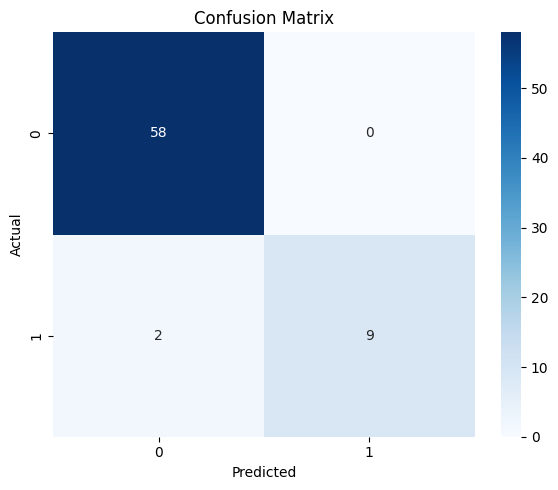


Binary ROC-AUC Score: 0.9514


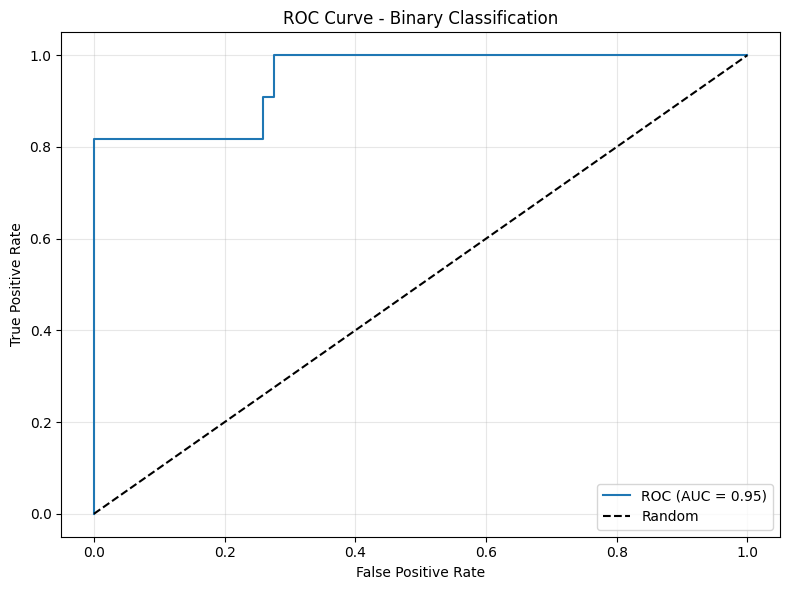

In [72]:
evaluate_model(xgb_model, X_test, y_test)

The XGBoost model achieved an overall accuracy of 97% with a macro F1-score of 0.94. It demonstrated strong minority class performance with 0.82 recall and perfect precision (1.00), indicating effective and balanced classification.

In [73]:
import joblib
joblib.dump(xgb_model, "final_xgb_model.pkl")


['final_xgb_model.pkl']

#### **Checking Overfitting**

===== TRAIN SET PERFORMANCE =====
<=== Classification Report ===>
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       230
           1       0.90      1.00      0.95        43

    accuracy                           0.98       273
   macro avg       0.95      0.99      0.97       273
weighted avg       0.98      0.98      0.98       273


=== Confusion Matrix ===>


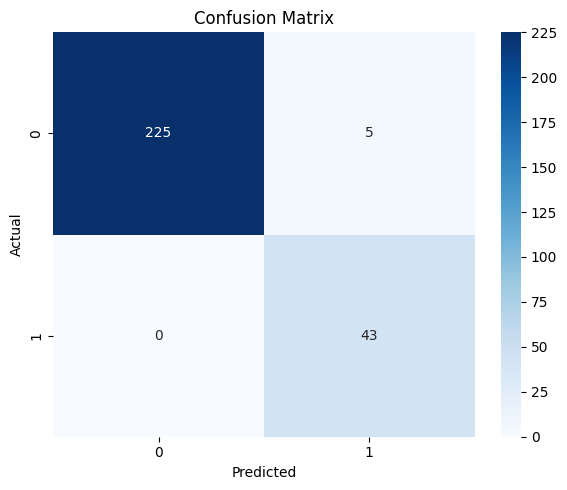


Binary ROC-AUC Score: 0.9999


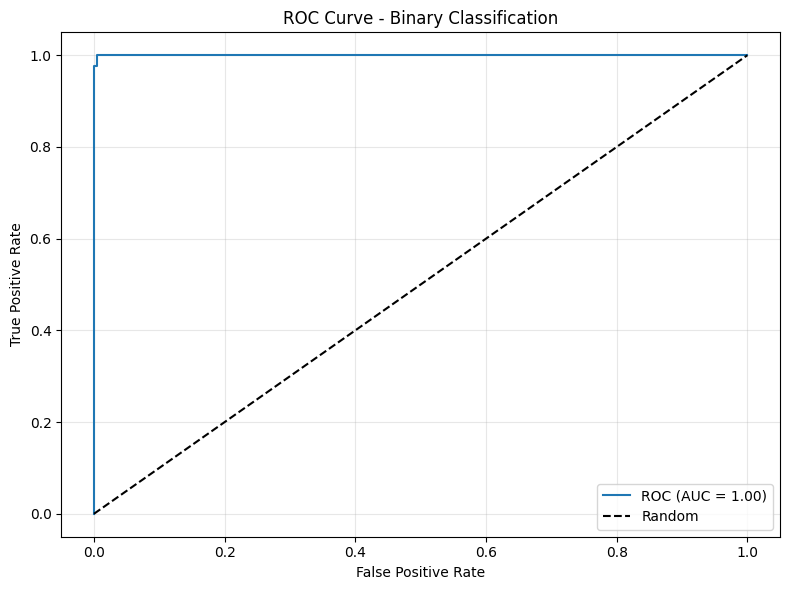


===== TEST SET PERFORMANCE =====
<=== Classification Report ===>
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.82      0.90        11

    accuracy                           0.97        69
   macro avg       0.98      0.91      0.94        69
weighted avg       0.97      0.97      0.97        69


=== Confusion Matrix ===>


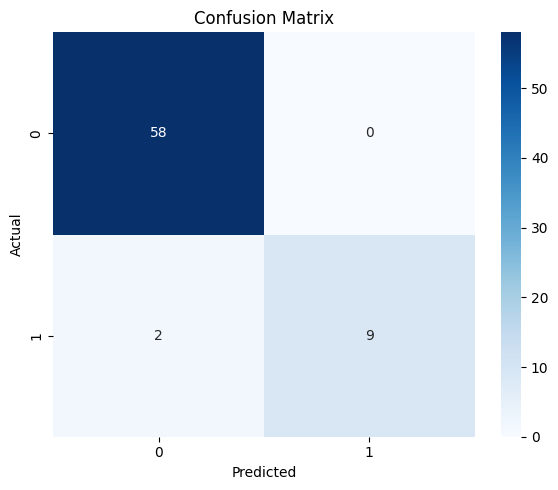


Binary ROC-AUC Score: 0.9514


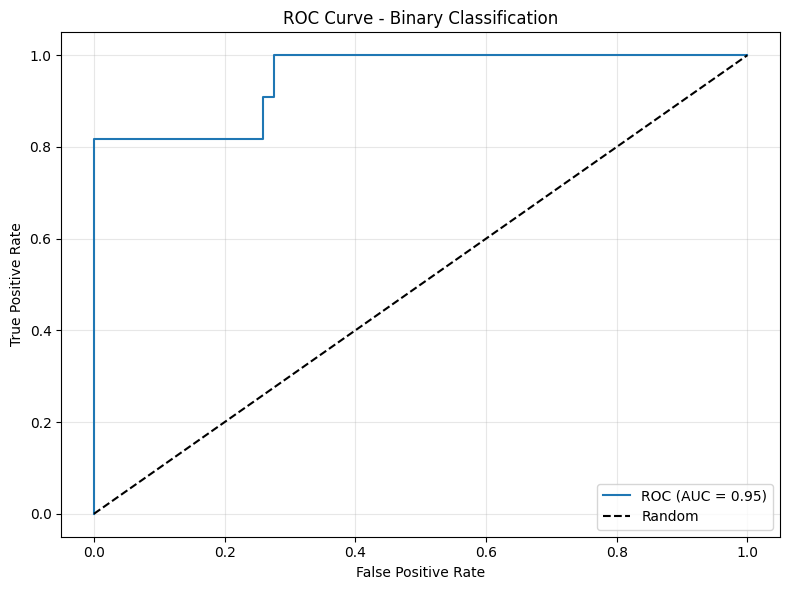

In [74]:
print("===== TRAIN SET PERFORMANCE =====")
evaluate_model(xgb_model, X_train, y_train)

print("\n===== TEST SET PERFORMANCE =====")
evaluate_model(xgb_model, X_test, y_test)

Overfitting was assessed by comparing training and testing performance metrics, including macro F1-score and ROC-AUC. The model achieved a macro F1-score of 0.97 on the training set and 0.94 on the test set, with ROC-AUC values of 1.00 (train) and 0.95 (test). The small performance gap indicates mild and expected variance, confirming that the model generalizes well without severe overfitting.

####  Cross- Validation & Hyperparameter Tuning

Starting Grid Search...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Grid Search Completed.

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.8}
Best CV Macro F1: 0.8156744163870245

Evaluating Best Model:
<=== Classification Report ===>
              precision    recall  f1-score   support

           0       0.96      0.95      0.96        58
           1       0.75      0.82      0.78        11

    accuracy                           0.93        69
   macro avg       0.86      0.88      0.87        69
weighted avg       0.93      0.93      0.93        69


=== Confusion Matrix ===>


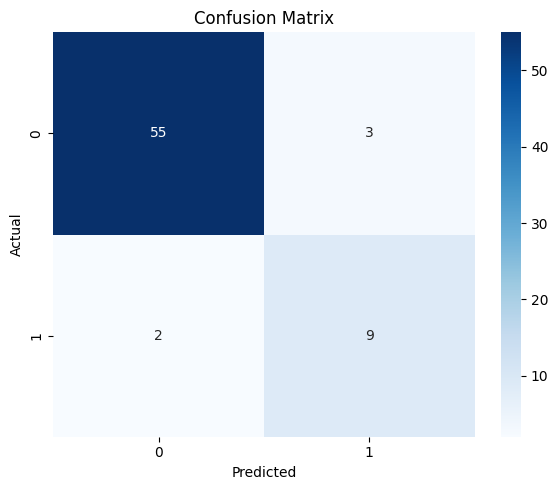


Binary ROC-AUC Score: 0.9389


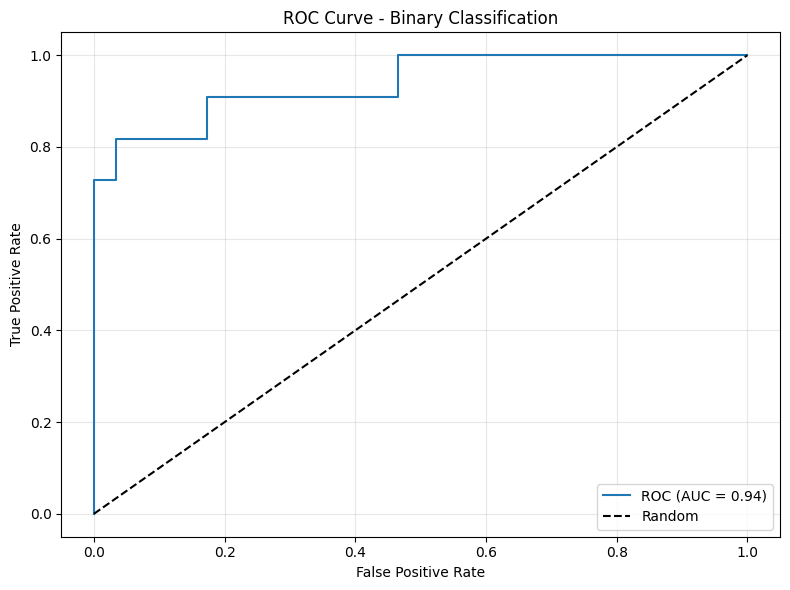

In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import traceback

# Compute imbalance ratio
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Better parameter grid
param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [2, 3, 4],           # shallow trees
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [3, 5, 7],
    'gamma': [0, 1]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=ratio,   # imbalance handling
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',   # important
    n_jobs=-1,
    verbose=1
)

try:
    print("Starting Grid Search...")
    grid_search.fit(X_train, y_train)
    print("Grid Search Completed.")

    best_xgb = grid_search.best_estimator_

    print("\nBest Parameters:", grid_search.best_params_)
    print("Best CV Macro F1:", grid_search.best_score_)

    print("\nEvaluating Best Model:")
    evaluate_model(best_xgb, X_test, y_test)

except Exception as e:
    print("Error during tuning:")
    traceback.print_exc()

Hyperparameter tuning with GridSearchCV did not improve performance compared to the default XGBoost configuration. Therefore, the default model was retained as it delivered better overall results.

###  Which ML model did you choose from the above created models as your final prediction model and why?

**Final Model Selected: XGBoost (with default configuration)**

XGBoost was selected as the final prediction model because it achieved the strongest and most balanced performance among all tested models. On the test set, it achieved 97% accuracy, 0.94 macro F1-score, and 0.95 ROC-AUC, demonstrating excellent overall classification capability. For the minority class, it delivered 0.82 recall and 1.00 precision, indicating strong detection of non-Class A samples with minimal false positives.

Compared to Logistic Regression and Random Forest, XGBoost provided the best balance between minority class performance and overall stability. The small gap between training (macro F1 = 0.97) and testing (macro F1 = 0.94) further confirms that the model generalizes well without severe overfitting.

### Explaining the model  used and the feature importance using  model explainability tool

<Figure size 1000x800 with 0 Axes>

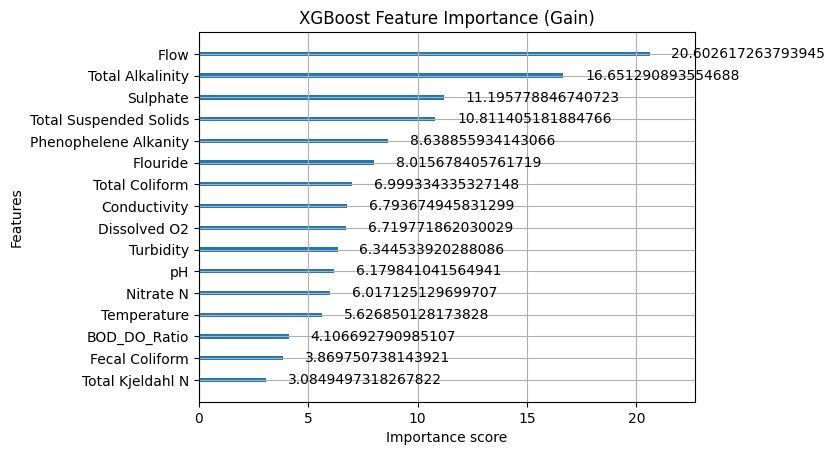

In [76]:
import joblib
from xgboost import plot_importance
import matplotlib.pyplot as plt

# load fitted model
xgb_model = joblib.load("final_xgb_model.pkl")

plt.figure(figsize=(10,8))
plot_importance(xgb_model, importance_type='gain')
plt.title("XGBoost Feature Importance (Gain)")
plt.show()


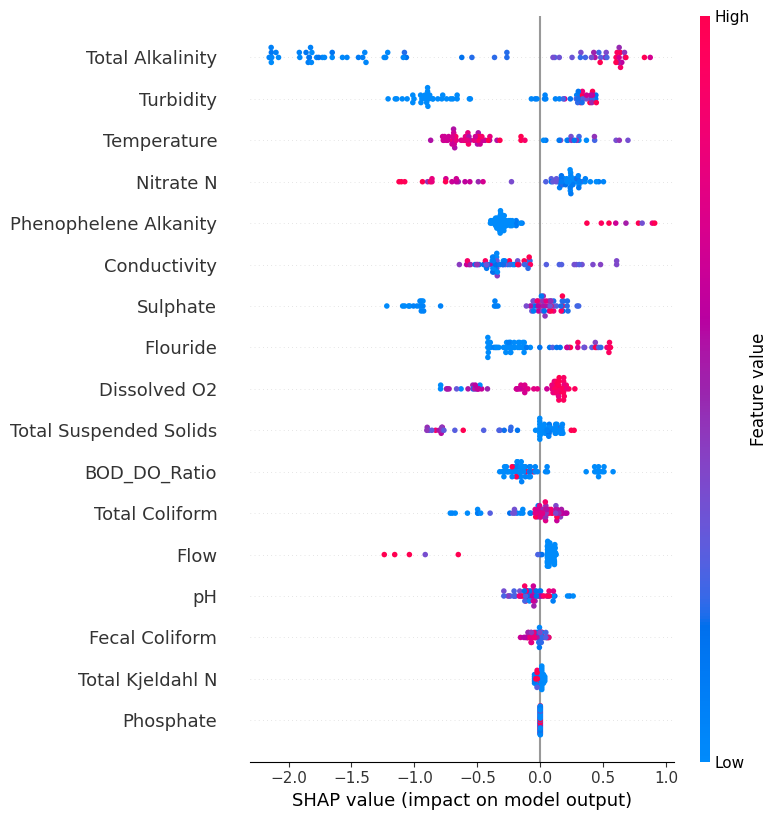

In [77]:
import shap  #  SHAP is used to explain model predictions (like showing which feature did what)

# Create a TreeExplainer specifically for the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for each feature in X_test
# This gives how much each feature pushed the prediction up or down
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary to visualize global feature importance
# It shows: which features are important AND how their values affect predictions (high vs. low)
# Increased plot size using matplotlib before plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))  # Change size here: width=12, height=8
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()



Model Explainability –-> XGBoost & SHAP Interpretation

The XGBoost gain-based feature importance identified Flow, Total Alkalinity, Sulphate, and Total Suspended Solids as the most influential features globally.

SHAP analysis provided deeper interpretability by showing both the magnitude and direction of feature impact on predictions. The High alkalinity,Phenophelene Alkanity and turbidity values increase the likelihood of lower-quality water classification. Low flow values   push predictions toward lower-quality water, while higher flow and high temperature  supports high-quality classification. Interestingly, higher dissolved oxygen values in this dataset were associated with increased probability of lower-quality classification, indicating dataset-specific patterns rather than purely theoretical relationships.

SHAP confirms that the model captures meaningful feature interactions influencing water quality classification.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [78]:
import joblib
import os

# If using Google Colab, mount drive first
from google.colab import drive
drive.mount('/content/drive')

# Define folder path
path = "/content/drive/MyDrive/ML Water Quality Classification & Public Health Analytics"

# Create directory if it does not exist
os.makedirs(path, exist_ok=True)

# Full file path
file_path = os.path.join(path, "final_xgb_model.pkl")

# Save the model
joblib.dump(xgb_model, file_path)

print(f"Model saved successfully at: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved successfully at: /content/drive/MyDrive/ML Water Quality Classification & Public Health Analytics/final_xgb_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [79]:
import joblib

# Define path
file_path = "/content/drive/MyDrive/ML Water Quality Classification & Public Health Analytics/final_xgb_model.pkl"

# Load model
loaded_model = joblib.load(file_path)

print("Model loaded successfully.")

Model loaded successfully.


In [80]:
import numpy as np

np.array_equal(
    xgb_model.predict(X_test),
    loaded_model.predict(X_test)
)

True

### Final Prediction: Verifying Model on Real-World-Like Data

In [81]:
list(X_train.columns)


['Total Suspended Solids',
 'Total Alkalinity',
 'Conductivity',
 'Temperature',
 'Dissolved O2',
 'Turbidity',
 'BOD_DO_Ratio',
 'Sulphate',
 'Nitrate N',
 'Phenophelene Alkanity',
 'pH',
 'Fecal Coliform',
 'Total Coliform',
 'Flouride',
 'Flow',
 'Total Kjeldahl N',
 'Phosphate']

In [87]:
import joblib
import pandas as pd
import numpy as np

# Load final model
model = joblib.load("final_xgb_model.pkl")

# Final feature order (MUST match training)
feature_order = [
    'Total Suspended Solids',
    'Total Alkalinity',
    'Conductivity',
    'Temperature',
    'Dissolved O2',
    'Turbidity',
    'BOD_DO_Ratio',
    'Sulphate',
    'Nitrate N',
    'Phenophelene Alkanity',
    'pH',
    'Fecal Coliform',
    'Total Coliform',
    'Flouride',
    'Flow',
    'Total Kjeldahl N',
    'Phosphate'
]

# Columns that were log1p transformed during training
log_columns = [
    'Conductivity',
    'Turbidity',
    'Sulphate',
    'Fecal Coliform',
    'Total Coliform'
]

# ----------------------------
# Case 1: High Quality Water (Class A)
# ----------------------------
case_class_A = {
    'Total Suspended Solids': 10,
    'Total Alkalinity': 80,
    'Conductivity': 200,
    'Temperature': 29,
    'Dissolved O2': 7.5,
    'Turbidity': 1,
    'BOD_DO_Ratio': 0.15,
    'Sulphate': 15,
    'Nitrate N': 1.2,
    'Phenophelene Alkanity': 5,
    'pH': 7.9,
    'Fecal Coliform': 20,
    'Total Coliform': 150,
    'Flouride': 0.4,
    'Flow': 3,
    'Total Kjeldahl N': 1.5,
    'Phosphate': 0.2
}

# ----------------------------
# Case 2: Lower Quality Water (Non-Class A)
# ----------------------------
case_non_A = {
    'Total Suspended Solids': 60,
    'Total Alkalinity': 180,
    'Conductivity': 2000,
    'Temperature': 24,
    'Dissolved O2': 4.5,
    'Turbidity': 20,
    'BOD_DO_Ratio': 0.6,
    'Sulphate': 300,
    'Nitrate N': 0.3,
    'Phenophelene Alkanity': 20,
    'pH': 8.5,
    'Fecal Coliform': 500,
    'Total Coliform': 2000,
    'Flouride': 1.5,
    'Flow': 0,
    'Total Kjeldahl N': 5,
    'Phosphate': 1.2
}

# Put both cases together
test_cases = [case_class_A, case_non_A]

for i, case in enumerate(test_cases, start=1):

    df = pd.DataFrame([case])

    # Apply log1p transformation
    for col in log_columns:
        df[col] = np.log1p(df[col])

    df = df[feature_order]

    prediction = model.predict(df)

    print(f"\nTest Case {i} Prediction:", prediction[0])

    if prediction[0] == 0:
        print("→ Predicted: High Quality Water (Class A)")
    else:
        print("→ Predicted: Lower Quality Water (Non-Class A)")


Test Case 1 Prediction: 0
→ Predicted: High Quality Water (Class A)

Test Case 2 Prediction: 1
→ Predicted: Lower Quality Water (Non-Class A)


# **Conclusion**

This project focused on developing a reliable machine learning system for water quality classification using environmental and chemical parameters. The original dataset contained 444 samples across four designated water quality classes. Due to severe class imbalance and very limited samples in certain categories, the problem was strategically reformulated into a binary classification task, distinguishing High Quality (Class A) water from Lower Quality (Classes B, C, and E) water to ensure stable and meaningful modeling.

An 80–20 stratified train-test split was applied to preserve class distribution. Constant and highly correlated features were removed to reduce redundancy and multicollinearity. Based on Random Forest importance, 17 key environmental features were selected for modeling.

Among all evaluated models, the default XGBoost classifier delivered the best performance, achieving 97 percent test accuracy, 0.94 macro F1-score, strong minority class recall of 0.82, and a ROC-AUC score of 0.95. The small gap between training and testing performance confirmed good generalization with minimal overfitting. Feature importance and SHAP analysis further validated that the model relied on scientifically meaningful parameters such as Flow, Turbidity, Total Alkalinity, and Dissolved Oxygen.

 this project demonstrates how machine learning can transform environmental monitoring data into a practical, interpretable, and high-performing decision-support tool that assists in efficient water quality assessment and public health management.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***